# ERA5 Weather Field Reconstruction

Reconstruct 2 m temperature and five weather variables from simulated sparse observations.

## 0. Dependencies

### 0.1 Install mapping dependency

In [4]:
%pip install cartopy

## 1. Imports

### 1.1 Install Zarr support

In [5]:
# À exécuter dans une cellule Jupyter AVANT open_dataset()
import sys
!{sys.executable} -m pip install -q "zarr>=2.18" "fsspec>=2024.0.0" "gcsfs>=2024.0.0"

import zarr
import xarray as xr

print("zarr OK:", zarr.__version__)
print("xarray OK:", xr.__version__)


zarr OK: 3.2.1
xarray OK: 2025.12.0


### 1.2 Import libraries

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.spatial import cKDTree
import xarray as xr
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity
except Exception:
    structural_similarity = None


## 2. Configuration

### 2.1 Set experiment parameters

In [7]:
# ── Données ────────────────────────────────────────────────────────────────
ERA5_PATH    = "gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr"
TIME_SLICE   = slice(0, 2000)
LEVEL_TARGET = 850

VAR_CANDIDATES = {
    "u":   ["10m_u_component_of_wind", "u10"],
    "v":   ["10m_v_component_of_wind", "v10"],
    "z":   ["geopotential", "z"],
    "q":   ["specific_humidity", "q"],
    "t2m": ["2m_temperature", "t2m"],
}
MULTIVAR_KEYS = ["z", "q", "t2m", "u", "v"]

# ── Capteurs / masque ──────────────────────────────────────────────────────
KEEP_RATIO   = 0.1
A_KEEP_RATIO = 0.05   # Section A explicite à 5% pour reproductibilité des notes
SEED_TRAIN = 10
SEED_VAL   = 20
SEED_TEST  = 30

# ── Split ──────────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

# ── Entraînement ──────────────────────────────────────────────────────────
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_EVAL  = 32
LR               = 1e-3
WEIGHT_DECAY     = 1e-4
MAX_EPOCHS       = 30
PATIENCE         = 5

# ── Architecture ──────────────────────────────────────────────────────────
UNET_BASE = 64

# ── Architecture GNN ──────────────────────────────────────────────────────
GNN_HIDDEN_DIM = 128
GNN_NUM_LAYERS = 4
GNN_KNN_K      = 8

# ── Loss multivariée ──────────────────────────────────────────────────────
# Référence potentielle de pondération par variable.
# Non utilisée tant que FIXED_LOSS_WEIGHTS reste à None.
MULTIVAR_WEIGHTS = [1, 1, 1, 1, 1]  # (z, q, t2m, u, v)
WEIGHT_UNKNOWN   = 0.8
WEIGHT_ALL       = 0.2
LAMBDA_GRAD      = 2.5             # poids gradient loss (augmenter → moins de lissage)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

# Reproductibilité complète
GLOBAL_SEED = 42
torch.manual_seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)
print(f"Seeds fixées : {GLOBAL_SEED}")


Device : cuda
Seeds fixées : 42


## 3. Load ERA5 data

### 3.1 Load ERA5

In [8]:
def open_dataset():
    """Ouvre ERA5 depuis Google Cloud Storage (accès anonyme)."""
    ds = xr.open_zarr(ERA5_PATH, storage_options={"token": "anon"})
    return ds


def to_THW(da, level_target=LEVEL_TARGET, time_slice=TIME_SLICE):
    """Extrait un DataArray ERA5 en array float32 (T, H, W)."""
    if "level" in da.dims:
        da = da.sel(level=level_target, method="nearest")
    da = da.isel(time=time_slice)
    lat_dim = next((d for d in da.dims if d in ("lat", "latitude")), None)
    lon_dim = next((d for d in da.dims if d in ("lon", "longitude")), None)
    da = da.transpose("time", lat_dim, lon_dim)
    return da.astype("float32").values


def get_lat_weights_2d(ds):
    """Poids latitude cos(lat), normalisés à moyenne 1, shape (H,W)."""
    lat_name = "lat" if "lat" in ds.coords else ("latitude" if "latitude" in ds.coords else None)
    lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
    if lat_name is None or lon_name is None:
        raise RuntimeError("Coordonnées lat/lon introuvables pour calculer les poids latitude.")

    lat = np.asarray(ds[lat_name].values, dtype=np.float32)
    lon = np.asarray(ds[lon_name].values, dtype=np.float32)
    w_lat = np.cos(np.deg2rad(lat)).astype(np.float32)
    w_lat = np.clip(w_lat, 1e-6, None)

    w2d = np.repeat(w_lat[:, None], len(lon), axis=1)
    w2d = w2d / (float(np.mean(w2d)) + 1e-12)
    return w2d.astype(np.float32)


def build_climatology_univariate(T_train: np.ndarray) -> np.ndarray:
    """Climatologie 2D pour ACC: moyenne temporelle sur split train."""
    if T_train.ndim != 3:
        raise ValueError(f"T_train doit être (T,H,W), reçu {T_train.shape}")
    return T_train.mean(axis=0).astype(np.float32)


def build_climatology_maps(fields: dict, keys: list, idx_train: np.ndarray) -> dict:
    """Climatologie 2D par variable sur split train."""
    maps = {}
    for k in keys:
        maps[k] = fields[k][idx_train].mean(axis=0).astype(np.float32)
    return maps


def load_fields(ds, keys):
    """Charge plusieurs variables et retourne un dict {clé: array (T,H,W)}."""
    fields = {}
    for k in keys:
        candidates = VAR_CANDIDATES[k]
        vname = next((c for c in candidates if c in ds.data_vars), None)
        if vname is None:
            print(f"[loader] Variable '{k}' introuvable, ignorée.")
            continue
        fields[k] = to_THW(ds[vname])
        print(f"[loader] {k} ({vname}): {fields[k].shape}")
    return fields


def compute_split_indices(n, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    """Split temporel 70/15/15 → (idx_train, idx_val, idx_test)."""
    n_train = int(train_ratio * n)
    n_val   = int(val_ratio * n)
    return (np.arange(0, n_train),
            np.arange(n_train, n_train + n_val),
            np.arange(n_train + n_val, n))


def compute_stats(fields, idx_train):
    """Calcule moyenne et écart-type sur le split train uniquement."""
    means, stds = {}, {}
    for k, arr in fields.items():
        means[k] = float(arr[idx_train].mean())
        stds[k]  = float(arr[idx_train].std() + 1e-6)
        print(f"[loader] {k}: mu={means[k]:.4f}, sigma={stds[k]:.4f}")
    return means, stds


## 4. Sparse masks and Voronoi interpolation

### 4.1 Define masks and Voronoi interpolation

In [9]:
def make_sparse_mask(h, w, keep_ratio=KEEP_RATIO, rng=None):
    """Masque binaire (H,W) float32 avec keep_ratio*H*W pixels à 1."""
    rng = np.random.default_rng() if rng is None else rng
    n = h * w
    k = max(1, int(round(keep_ratio * n)))
    idx = rng.choice(n, size=k, replace=False)
    m = np.zeros(n, dtype=np.float32)
    m[idx] = 1.0
    return m.reshape(h, w)


def voronoi_fill_from_sparse(field, mask):
    """Interpolation plus proche voisin depuis les capteurs (mask==1)."""
    ys, xs = np.where(mask == 1)
    vals = field[ys, xs]
    pts  = np.stack([ys, xs], axis=1)
    gy, gx = np.meshgrid(np.arange(field.shape[0]), np.arange(field.shape[1]), indexing="ij")
    query = np.stack([gy.ravel(), gx.ravel()], axis=1)
    tree = cKDTree(pts)
    _, nn = tree.query(query, k=1)
    return vals[nn].reshape(field.shape).astype(np.float32)

## 5. PyTorch datasets

### 5.1 Define datasets

In [10]:
class SparseVoronoiDataset(Dataset):
    """
    Dataset univarié.
    Retourne : x (3,H,W), y (1,H,W), m (1,H,W)
    """
    def __init__(self, T, mu, sigma, keep_ratio=KEEP_RATIO, base_seed=0,
                 absolute_indices=None):
        self.T, self.mu, self.sigma = T, mu, sigma
        self.keep_ratio, self.base_seed = keep_ratio, base_seed
        if absolute_indices is None:
            self.absolute_indices = np.arange(len(T), dtype=int)
        else:
            self.absolute_indices = np.array(absolute_indices, dtype=int)
            if len(self.absolute_indices) != len(T):
                raise ValueError("absolute_indices doit avoir la même longueur que T")

    def __len__(self):
        return len(self.T)

    def __getitem__(self, i):
        field = self.T[i]
        t_abs = int(self.absolute_indices[i])
        rng   = np.random.default_rng(self.base_seed + t_abs)
        mask  = make_sparse_mask(field.shape[0], field.shape[1], self.keep_ratio, rng)
        vor   = voronoi_fill_from_sparse(field, mask)
        sparse = field * mask

        x = np.stack([(vor - self.mu) / self.sigma,
                       mask,
                       (sparse - self.mu) / self.sigma], axis=0)
        y = ((field - self.mu) / self.sigma)[None]
        m = mask[None]
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(m, dtype=torch.float32))


class MultiSparseVoronoiDataset(Dataset):
    """
    Dataset multivarié (K variables).
    Retourne : x (3*K,H,W), y (K,H,W), m (K,H,W)
    """
    def __init__(self, fields, keys, means, stds, indices,
                 keep_ratio=KEEP_RATIO, base_seed=0, different_masks=False):
        self.fields, self.keys   = fields, list(keys)
        self.means, self.stds    = means, stds
        self.indices             = np.array(indices, dtype=int)
        self.keep_ratio          = keep_ratio
        self.base_seed           = base_seed
        self.different_masks     = different_masks
        _, self.H, self.W = fields[self.keys[0]].shape

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t = int(self.indices[i])
        rng_main    = np.random.default_rng(self.base_seed + t)
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch, y_ch, m_ch = [], [], []
        for vi, k in enumerate(self.keys):
            field = self.fields[k][t]
            mu, sig = self.means[k], self.stds[k]
            if self.different_masks:
                rng_k = np.random.default_rng(self.base_seed + t * 1000 + vi)
                mask  = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask
            vor    = voronoi_fill_from_sparse(field, mask)
            sparse = field * mask
            x_ch += [(vor - mu) / sig, mask.astype(np.float32), (sparse - mu) / sig]
            y_ch.append(((field - mu) / sig).astype(np.float32))
            m_ch.append(mask.astype(np.float32))

        return (torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32),
                torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32),
                torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32))


## 6. StrongUNet architecture

### 6.1 Define StrongUNet

In [11]:
# models/trueunet.py — architecture StrongUNet (univarié et multivarié)
#
# Améliorations :
#   - Connexions résiduelles dans chaque ConvBlock (style ResNet)
#   - Skip connections denses (style U-Net++)
#   - CBAM (Channel + Spatial Attention) après chaque bloc résiduel
#   - BatchNorm + Dropout2d au bottleneck

import torch
import torch.nn as nn


# ── CBAM ──────────────────────────────────────────────────────────────────────

class ChannelAttention(nn.Module):
    """
    Recalibre l'importance de chaque canal (feature map).

    AvgPool + MaxPool → MLP partagé → sigmoid → poids par canal
    reduction : facteur de compression du MLP (défaut 16)
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )

    def forward(self, x):                          # x : (B, C, H, W)
        avg = x.mean(dim=(2, 3))                   # (B, C)
        mx  = x.amax(dim=(2, 3))                   # (B, C)
        w   = torch.sigmoid(self.mlp(avg) + self.mlp(mx))  # (B, C)
        return x * w[:, :, None, None]


class SpatialAttention(nn.Module):
    """
    Recalibre l'importance de chaque position spatiale (détection de motifs globaux).

    [AvgPool(C), MaxPool(C)] → concat → Conv 7×7 → sigmoid → poids spatial
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):                          # x : (B, C, H, W)
        avg = x.mean(dim=1, keepdim=True)          # (B, 1, H, W)
        mx  = x.amax(dim=1, keepdim=True)          # (B, 1, H, W)
        w   = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))  # (B, 1, H, W)
        return x * w


class CBAM(nn.Module):
    """
    Convolutional Block Attention Module (Woo et al., 2018).
    Channel Attention → Spatial Attention en séquence.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


# ── ConvBlock résiduel + CBAM ─────────────────────────────────────────────────

class ConvBlock(nn.Module):
    """
    Double conv → BN avec connexion résiduelle (ResNet) et CBAM.

    Structure :
        x → Conv→BN→ReLU→Conv→BN → + shortcut(x) → CBAM → ReLU → [Dropout2d]

    Le CBAM recalibre canaux et positions spatiales avant le ReLU final.
    """
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in,  c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
        )
        self.shortcut = (
            nn.Sequential(nn.Conv2d(c_in, c_out, 1, bias=False),
                          nn.BatchNorm2d(c_out))
            if c_in != c_out else nn.Identity()
        )
        self.cbam    = CBAM(c_out)
        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, x):
        out = self.cbam(self.conv(x) + self.shortcut(x))
        return self.dropout(self.relu(out))


# ── StrongUNet ────────────────────────────────────────────────────────────────

class StrongUNet(nn.Module):
    """
    U-Net à 3 niveaux avec :
      - Connexions résiduelles dans chaque ConvBlock (ResNet)
      - CBAM (Channel + Spatial Attention) après chaque bloc
      - Skip connections denses (U-Net++) :
            d3 ← up(b)  + e3
            d2 ← up(d3) + e2 + pool(e1)
            d1 ← up(d2) + e1 + up(e2)

    Paramètres
    ----------
    in_ch   : 3 (univarié) ou 3*K (multivarié)
    out_ch  : 1 (univarié) ou K   (multivarié)
    base    : canaux de base (×2 à chaque niveau, ×8 au goulot)
    dropout : Dropout2d au bottleneck

    Canaux (base=64) :
        e1 →  64  | pleine résolution  (32×64)
        e2 → 128  | /2                 (16×32)
        e3 → 256  | /4                 ( 8×16)
        b  → 512  | /8 — goulot        ( 4× 8)
    """

    def __init__(self, in_ch: int = 3, out_ch: int = 1,
                 base: int = 64, dropout: float = 0.3):
        super().__init__()

        # ── Encodeur ──────────────────────────────────────────────────────────
        self.e1 = ConvBlock(in_ch,    base)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlock(base,     base * 2)
        self.p2 = nn.MaxPool2d(2)
        self.e3 = ConvBlock(base * 2, base * 4)
        self.p3 = nn.MaxPool2d(2)

        # ── Goulot ────────────────────────────────────────────────────────────
        self.b  = ConvBlock(base * 4, base * 8, dropout=dropout)

        # ── Décodeur niveau 3 : cat(up(b), e3) → 512+256=768 → 256 ──────────
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.d3 = ConvBlock(base * 8, base * 4)

        # ── Décodeur niveau 2 : cat(up(d3), e2, pool(e1)) → 256+128+64=448 → 128
        self.u2           = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.pool_e1_to_2 = nn.MaxPool2d(2)
        self.d2           = ConvBlock(base * 4 + base, base * 2)

        # ── Décodeur niveau 1 : cat(up(d2), e1, up(e2)) → 128+64+128=320 → 64
        self.u1         = nn.ConvTranspose2d(base * 2, base,     2, stride=2)
        self.up_e2_to_1 = nn.ConvTranspose2d(base * 2, base * 2, 2, stride=2)
        self.d1         = ConvBlock(base + base + base * 2, base)

        # ── Sortie ────────────────────────────────────────────────────────────
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        # Encodeur
        e1 = self.e1(x)
        e2 = self.e2(self.p1(e1))
        e3 = self.e3(self.p2(e2))
        b  = self.b(self.p3(e3))

        # Décodeur niveau 3
        d3 = self.d3(torch.cat([self.u3(b), e3], dim=1))

        # Décodeur niveau 2 : + e1 downsamplé
        e1_down = self.pool_e1_to_2(e1)
        d2 = self.d2(torch.cat([self.u2(d3), e2, e1_down], dim=1))

        # Décodeur niveau 1 : + e2 upsamplé
        e2_up = self.up_e2_to_1(e2)
        d1 = self.d1(torch.cat([self.u1(d2), e1, e2_up], dim=1))

        return self.out(d1)


# ── Baseline Fukami (sans skip connections) ─────────────────────────────────

class ConvBlockPlain(nn.Module):
    """Bloc conv simple (pas de résidu, pas de skip global)."""
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class FukamiBaseline(nn.Module):
    """
    Baseline encodeur-décodeur sans skip connections.
    Sert de référence "modèle de base" pour comparaison avec StrongUNet.
    """
    def __init__(self, in_ch: int, out_ch: int, base: int = 64, dropout: float = 0.2):
        super().__init__()
        self.e1 = ConvBlockPlain(in_ch, base)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlockPlain(base, base * 2)
        self.p2 = nn.MaxPool2d(2)
        self.b  = ConvBlockPlain(base * 2, base * 4)
        self.drop = nn.Dropout2d(dropout)

        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.d2 = ConvBlockPlain(base * 2, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.d1 = ConvBlockPlain(base, base)

        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        x = self.e1(x)
        x = self.e2(self.p1(x))
        x = self.b(self.p2(x))
        x = self.d2(self.u2(self.drop(x)))
        x = self.d1(self.u1(x))
        return self.out(x)


## 7. Loss functions

### 7.1 Define losses

In [12]:
def gradient_loss(pred, y):
    """
    Pénalise les différences de gradients spatiaux entre pred et GT.
    Force la reconstruction des contours et structures fines (fronts, etc.)
    pred, y : (B, C, H, W)
    """
    gx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    gx_gt   = y[:, :, :, 1:]   - y[:, :, :, :-1]
    gy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    gy_gt   = y[:, :, 1:, :]   - y[:, :, :-1, :]
    return ((gx_pred - gx_gt) ** 2).mean() + ((gy_pred - gy_gt) ** 2).mean()


def loss_fn(pred, y, m):
    """Loss univariée : priorité aux points non observés + gradient loss."""
    unknown   = 1.0 - m
    l_unknown = ((pred - y) ** 2 * unknown).sum() / (unknown.sum() + 1e-6)
    l_all     = ((pred - y) ** 2).mean()
    l_mse     = WEIGHT_UNKNOWN * l_unknown + WEIGHT_ALL * l_all
    return l_mse + LAMBDA_GRAD * gradient_loss(pred, y)


def loss_fn_mv(pred, y, m, weights, device=device):
    """Loss multivariée avec poids adaptatifs + gradient loss."""
    w    = torch.tensor(weights, dtype=torch.float32, device=device)
    err2 = (pred - y) ** 2 * w[None, :, None, None]
    unknown   = 1.0 - m
    l_unknown = (err2 * unknown).sum() / (unknown.sum() + 1e-6)
    l_all     = err2.mean()
    l_mse     = WEIGHT_UNKNOWN * l_unknown + WEIGHT_ALL * l_all
    return l_mse + LAMBDA_GRAD * gradient_loss(pred, y)


def compute_adaptive_weights(nrmse_dict, keys):
    """poids_k = NRMSE_k / mean(NRMSE) — somme des poids = K."""
    vals  = [nrmse_dict[k] for k in keys]
    total = sum(vals)
    K     = len(keys)
    return [v / total * K for v in vals]


## 8. Training loops

### 8.1 Define training loops

In [13]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn_callable,
                device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Boucle d'entraînement générique avec early stopping (univarié)."""
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_callable(model(x), y, m)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_callable(model(x), y, m).item())

        tr_mean, va_mean = float(np.mean(tr_losses)), float(np.mean(va_losses))
        print(f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f}", flush=True)

        if va_mean < best_val - 1e-5:
            best_val   = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


def train_model_adaptive(model, train_loader, val_loader, optimizer, keys,
                         device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """
    Boucle multivariée avec poids adaptatifs.

    Correctifs:
    - NRMSE de référence calculée en global epoch (SSE/N), pas moyenne de RMSE batch.
    - Early stopping sur val_nrmse_mean_ref (échelle fixe inter-epochs).
    """
    K = len(keys)
    weights = [1.0] * K
    best_ref, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        # ── Entraînement ───────────────────────────────────────────────────
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        # ── Validation: diagnostic adaptatif + NRMSE ref (SSE/N) ───────────
        model.eval()
        va_losses_adaptive = []
        sse_ref = {k: 0.0 for k in keys}
        n_ref = {k: 0.0 for k in keys}

        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                pred = model(x)
                va_losses_adaptive.append(loss_fn_mv(pred, y, m, weights, device).item())

                for i, k in enumerate(keys):
                    e2 = (pred[:, i] - y[:, i]) ** 2
                    sse_ref[k] += float(e2.sum().item())
                    n_ref[k] += float(e2.numel())

        nrmse_mean = {
            k: float(np.sqrt(sse_ref[k] / max(n_ref[k], 1.0)))
            for k in keys
        }
        val_nrmse_mean_ref = float(np.mean([nrmse_mean[k] for k in keys]))

        # Mise à jour des poids pour l'epoch suivante
        weights = compute_adaptive_weights(nrmse_mean, keys)

        tr_mean = float(np.mean(tr_losses))
        va_adapt_mean = float(np.mean(va_losses_adaptive))
        w_str = " | ".join(f"{k}={weights[i]:.3f}" for i, k in enumerate(keys))
        print(
            f"Epoch {epoch:02d} | train={tr_mean:.5f} | val_adapt={va_adapt_mean:.5f} | "
            f"val_nrmse_ref={val_nrmse_mean_ref:.5f} | poids [{w_str}]",
            flush=True,
        )

        # ── Early stopping sur métrique fixe ───────────────────────────────
        if val_nrmse_mean_ref < best_ref - 1e-5:
            best_ref = val_nrmse_mean_ref
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val_nrmse_ref : {best_ref:.5f}", flush=True)
    return model


def train_model_fixed_weights(model, train_loader, val_loader, optimizer, keys,
                              device, fixed_weights=None,
                              max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Boucle multivariée avec poids fixes (pas d'ajustement adaptatif)."""
    K = len(keys)
    if fixed_weights is None:
        weights = [1.0] * K
    else:
        if len(fixed_weights) != K:
            raise ValueError(f"fixed_weights doit avoir longueur {K}, reçu {len(fixed_weights)}")
        weights = [float(w) for w in fixed_weights]

    print(
        "[train_model_fixed_weights] Note: val_loss comparable intra-run uniquement; "
        "inter-run, comparer plutôt NRMSE/ACC/SSIM.",
        flush=True,
    )

    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_mv(model(x), y, m, weights, device).item())

        tr_mean = float(np.mean(tr_losses))
        va_mean = float(np.mean(va_losses))
        w_str = " | ".join(f"{k}={weights[i]:.2f}" for i, k in enumerate(keys))
        print(f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f} | poids fixes [{w_str}]", flush=True)

        if va_mean < best_val - 1e-5:
            best_val   = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


## 9. Evaluation metrics

### 9.1 Define evaluation metrics

In [14]:
# evaluate.py — RMSE/NRMSE + ACC climatologique (WeatherBench simplifié) + SSIM locale

import numpy as np
import torch

try:
    from skimage.metrics import structural_similarity
except Exception:
    structural_similarity = None


def _resolve_lat_weights(lat_weights_2d):
    if lat_weights_2d is not None:
        return np.asarray(lat_weights_2d, dtype=np.float32)
    for name in ["LAT_WEIGHTS_2D_A", "LAT_WEIGHTS_2D_B", "LAT_WEIGHTS_2D", "LAT_WEIGHTS_2D_F", "LAT_WEIGHTS_2D_D", "LAT_WEIGHTS_2D_E"]:
        if name in globals():
            return np.asarray(globals()[name], dtype=np.float32)
    raise RuntimeError("Poids latitude introuvables. Calculer get_lat_weights_2d(ds) avant l'évaluation.")


def _resolve_clim_uni(climatology_map):
    if climatology_map is not None:
        return np.asarray(climatology_map, dtype=np.float32)
    for name in ["CLIM_UNI_MAP_A", "CLIM_UNI_MAP"]:
        if name in globals():
            return np.asarray(globals()[name], dtype=np.float32)
    raise RuntimeError("Climatologie univariée introuvable. Construire CLIM_UNI_MAP_A sur le train.")


def _resolve_clim_mv(climatology_maps, keys):
    if climatology_maps is not None:
        return {k: np.asarray(climatology_maps[k], dtype=np.float32) for k in keys}
    for name in ["CLIM_MV_MAPS_B", "CLIM_MV_MAPS", "CLIM_MV_MAPS_D", "CLIM_MV_MAPS_E", "CLIM_MV_MAPS_F"]:
        if name in globals():
            src = globals()[name]
            if isinstance(src, dict) and all(k in src for k in keys):
                return {k: np.asarray(src[k], dtype=np.float32) for k in keys}
    raise RuntimeError("Climatologie multivariée introuvable. Construire build_climatology_maps(...) sur le train.")


def ssim_2d(pred: np.ndarray, gt: np.ndarray) -> float:
    """SSIM locale (fenêtre glissante), version skimage standard."""
    if structural_similarity is None:
        raise ImportError("skimage.metrics.structural_similarity indisponible. Installer scikit-image.")

    pred = np.asarray(pred, dtype=np.float32)
    gt = np.asarray(gt, dtype=np.float32)
    data_min = float(min(pred.min(), gt.min()))
    data_max = float(max(pred.max(), gt.max()))
    data_range = max(data_max - data_min, 1e-6)

    h, w = pred.shape
    max_win = min(h, w)
    if max_win % 2 == 0:
        max_win -= 1
    win = min(11, max_win)
    if win < 3:
        return float("nan")

    return float(
        structural_similarity(
            gt,
            pred,
            data_range=data_range,
            gaussian_weights=True,
            sigma=1.5,
            use_sample_covariance=False,
            win_size=win,
        )
    )


def acc_2d(pred: np.ndarray, gt: np.ndarray, climatology_map: np.ndarray, lat_weights_2d: np.ndarray) -> float:
    """ACC WeatherBench simplifié: anomalies vs climatologie + pondération cos(lat)."""
    pred = np.asarray(pred, dtype=np.float64)
    gt = np.asarray(gt, dtype=np.float64)
    clim = np.asarray(climatology_map, dtype=np.float64)
    w = np.asarray(lat_weights_2d, dtype=np.float64)

    pa = pred - clim
    ga = gt - clim

    num = np.sum(w * pa * ga)
    den = np.sqrt(np.sum(w * pa * pa) * np.sum(w * ga * ga))
    if den < 1e-12:
        return float("nan")
    return float(num / den)


def evaluate_univariate(model, test_loader, mu: float, sigma: float,
                        device, climatology_map=None, lat_weights_2d=None) -> dict:
    """Évaluation univariée avec RMSE/NRMSE + ACC climatologique + SSIM locale."""
    model.eval()
    clim = _resolve_clim_uni(climatology_map)
    w_lat = _resolve_lat_weights(lat_weights_2d)

    sse_all, n_all = 0.0, 0.0
    sse_unknown, n_unknown = 0.0, 0.0
    acc_sum, acc_n = 0.0, 0
    ssim_sum, ssim_n = 0.0, 0

    with torch.no_grad():
        for x, y, m in test_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            pred = model(x)

            pred_k = pred * sigma + mu
            y_k = y * sigma + mu

            e2 = (pred_k - y_k) ** 2
            sse_all += float(e2.sum().item())
            n_all += float(e2.numel())

            unknown = 1.0 - m
            sse_unknown += float((e2 * unknown).sum().item())
            n_unknown += float(unknown.sum().item())

            pred_np = pred_k.squeeze(1).cpu().numpy()  # (B,H,W)
            y_np = y_k.squeeze(1).cpu().numpy()
            for b in range(pred_np.shape[0]):
                a = acc_2d(pred_np[b], y_np[b], clim, w_lat)
                if np.isfinite(a):
                    acc_sum += float(a)
                    acc_n += 1

                s = ssim_2d(pred_np[b], y_np[b])
                if np.isfinite(s):
                    ssim_sum += float(s)
                    ssim_n += 1

    rmse_g = float(np.sqrt(sse_all / max(n_all, 1.0)))
    rmse_u = float(np.sqrt(sse_unknown / max(n_unknown, 1.0)))

    return {
        "rmse_global": rmse_g,
        "rmse_unknown": rmse_u,
        "nrmse_global": rmse_g / sigma,
        "nrmse_unknown": rmse_u / sigma,
        "acc": float(acc_sum / max(acc_n, 1)),
        "ssim": float(ssim_sum / max(ssim_n, 1)),
    }


def evaluate_multivariate(model, test_loader, keys: list,
                          means: dict, stds: dict, device,
                          climatology_maps=None, lat_weights_2d=None) -> dict:
    """Évaluation multivariée avec ACC climatologique et SSIM locale."""
    model.eval()
    clim_maps = _resolve_clim_mv(climatology_maps, keys)
    w_lat = _resolve_lat_weights(lat_weights_2d)

    sse_all = {k: 0.0 for k in keys}
    n_all = {k: 0.0 for k in keys}
    sse_unknown = {k: 0.0 for k in keys}
    n_unknown = {k: 0.0 for k in keys}

    acc_sum = {k: 0.0 for k in keys}
    acc_n = {k: 0 for k in keys}
    ssim_sum = {k: 0.0 for k in keys}
    ssim_n = {k: 0 for k in keys}

    with torch.no_grad():
        for x, y, m in test_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            pred = model(x)

            for i, k in enumerate(keys):
                mu, sig = means[k], stds[k]
                pred_k = pred[:, i] * sig + mu
                y_k = y[:, i] * sig + mu

                e2 = (pred_k - y_k) ** 2
                sse_all[k] += float(e2.sum().item())
                n_all[k] += float(e2.numel())

                unknown = 1.0 - m[:, i]
                sse_unknown[k] += float((e2 * unknown).sum().item())
                n_unknown[k] += float(unknown.sum().item())

                pred_np = pred_k.cpu().numpy()
                y_np = y_k.cpu().numpy()
                clim_k = clim_maps[k]
                for b in range(pred_np.shape[0]):
                    a = acc_2d(pred_np[b], y_np[b], clim_k, w_lat)
                    if np.isfinite(a):
                        acc_sum[k] += float(a)
                        acc_n[k] += 1

                    s = ssim_2d(pred_np[b], y_np[b])
                    if np.isfinite(s):
                        ssim_sum[k] += float(s)
                        ssim_n[k] += 1

    results = {}
    for k in keys:
        rmse_g = float(np.sqrt(sse_all[k] / max(n_all[k], 1.0)))
        rmse_u = float(np.sqrt(sse_unknown[k] / max(n_unknown[k], 1.0)))
        results[k] = {
            "rmse_global": rmse_g,
            "rmse_unknown": rmse_u,
            "nrmse_global": rmse_g / stds[k],
            "nrmse_unknown": rmse_u / stds[k],
            "acc": float(acc_sum[k] / max(acc_n[k], 1)),
            "ssim": float(ssim_sum[k] / max(ssim_n[k], 1)),
        }
    return results


def evaluate_robustness(model, T_test, mu, sigma, device,
                        n_trials=5, keep_ratio=0.05, absolute_indices=None,
                        climatology_map=None, lat_weights_2d=None):
    """Robustesse sur tirages de masques avec métriques standardisées."""
    rmse_trials, acc_trials, ssim_trials = [], [], []

    if absolute_indices is None:
        absolute_indices = np.arange(len(T_test), dtype=int)
    else:
        absolute_indices = np.array(absolute_indices, dtype=int)

    for trial in range(n_trials):
        ds = SparseVoronoiDataset(
            T_test,
            mu=mu,
            sigma=sigma,
            keep_ratio=keep_ratio,
            base_seed=trial * 1000,
            absolute_indices=absolute_indices,
        )
        loader = DataLoader(ds, batch_size=32, shuffle=False)
        res = evaluate_univariate(
            model,
            loader,
            mu,
            sigma,
            device,
            climatology_map=climatology_map,
            lat_weights_2d=lat_weights_2d,
        )
        rmse_trials.append(res["rmse_global"])
        acc_trials.append(res["acc"])
        ssim_trials.append(res["ssim"])

    return {
        "rmse_mean": float(np.mean(rmse_trials)),
        "rmse_std": float(np.std(rmse_trials)),
        "acc_mean": float(np.nanmean(acc_trials)),
        "acc_std": float(np.nanstd(acc_trials)),
        "ssim_mean": float(np.mean(ssim_trials)),
        "ssim_std": float(np.std(ssim_trials)),
    }


def print_results_univariate(results: dict, var_name: str = "t2m"):
    print(f"\\n── Résultats {var_name} ──────────────────────────────")
    print(f"  RMSE global    : {results['rmse_global']:.4f}    NRMSE : {results['nrmse_global']:.4f}")
    print(f"  RMSE non-obs.  : {results['rmse_unknown']:.4f}    NRMSE : {results['nrmse_unknown']:.4f}")
    print(f"  ACC            : {results['acc']:.4f}")
    print(f"  SSIM           : {results['ssim']:.4f}")


def print_results_multivariate(results: dict):
    print("\\n── Résultats multivarié ──────────────────────────────────────────────────────────────────")
    print(f"  {'Var':>4s} | {'RMSE global':>12s} | {'NRMSE global':>12s} | {'RMSE non-obs.':>13s} | {'NRMSE non-obs.':>14s} | {'ACC':>6s} | {'SSIM':>6s}")
    print("  " + "-" * 87)
    for k, v in results.items():
        print(f"  {k:>4s} | {v['rmse_global']:>12.4f} | {v['nrmse_global']:>12.4f} | {v['rmse_unknown']:>13.4f} | {v['nrmse_unknown']:>14.4f} | {v['acc']:>6.4f} | {v['ssim']:>6.4f}")
    nrmse_global_mean = float(np.mean([v['nrmse_global'] for v in results.values()]))
    nrmse_unknown_mean = float(np.mean([v['nrmse_unknown'] for v in results.values()]))
    acc_mean = float(np.nanmean([v['acc'] for v in results.values()]))
    ssim_mean = float(np.mean([v['ssim'] for v in results.values()]))
    print("  " + "-" * 87)
    print(f"  {'moy.':>4s} | {'':12} | {nrmse_global_mean:>12.4f} | {'':13} | {nrmse_unknown_mean:>14.4f} | {acc_mean:>6.4f} | {ssim_mean:>6.4f}")

print("Fonctions evaluate définies (ACC climatologique WB simplifié + SSIM locale).")


Fonctions evaluate définies (ACC climatologique WB simplifié + SSIM locale).


## 10. Visualizations

### 10.1 Define visualizations

In [27]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.util import add_cyclic_point
    _HAS_CARTOPY = True
except Exception as _cartopy_exc:
    ccrs = None
    cfeature = None
    add_cyclic_point = None
    _HAS_CARTOPY = False
    print(f"[visualisation] Cartopy indisponible: {_cartopy_exc}. Les vues géographiques seront sautées.")


def _resolve_geo_coords(ds_geo=None):
    ds_obj = ds_geo if ds_geo is not None else globals().get("ds")
    if ds_obj is None:
        return None, None

    lat_name = next((name for name in ("lat", "latitude") if name in ds_obj.coords), None)
    lon_name = next((name for name in ("lon", "longitude") if name in ds_obj.coords), None)
    if lat_name is None or lon_name is None:
        return None, None

    lats = np.asarray(ds_obj[lat_name].values, dtype=np.float32)
    lons = np.asarray(ds_obj[lon_name].values, dtype=np.float32)
    return lats, lons


def _prepare_geo_field(field_2d, lats, lons):
    arr = np.asarray(field_2d, dtype=np.float32)
    lat_vals = np.asarray(lats, dtype=np.float32).copy()
    lon_vals = np.asarray(lons, dtype=np.float32).copy()

    lon_vals = ((lon_vals + 180.0) % 360.0) - 180.0
    lon_order = np.argsort(lon_vals)
    lon_vals = lon_vals[lon_order]
    arr = arr[:, lon_order]

    if lat_vals[0] > lat_vals[-1]:
        lat_vals = lat_vals[::-1]
        arr = arr[::-1, :]

    arr_cyclic, lon_cyclic = add_cyclic_point(arr, coord=lon_vals)
    return arr_cyclic, lat_vals, lon_cyclic


def _plot_geo_panel(ax, field_2d, title, cmap, vmin=None, vmax=None, ds_geo=None, alpha=0.95):
    lats, lons = _resolve_geo_coords(ds_geo)
    if (not _HAS_CARTOPY) or lats is None or lons is None:
        ax.set_axis_off()
        msg = "Cartopy indisponible" if not _HAS_CARTOPY else "Coords lat/lon introuvables"
        ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11)
        ax.set_title(title)
        return None

    field_geo, lats_geo, lons_geo = _prepare_geo_field(field_2d, lats, lons)
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor="#f5f7fa", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#ece6d8", edgecolor="none", zorder=0)
    mesh = ax.pcolormesh(
        lons_geo,
        lats_geo,
        field_geo,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
        zorder=1,
    )
    ax.coastlines(linewidth=0.6, color="black", zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.4, linestyle="--")
    ax.set_title(title)
    return mesh


def _plot_flat_panel(ax, field_2d, title, cmap, vmin=None, vmax=None):
    data = np.ma.masked_invalid(np.asarray(field_2d, dtype=np.float32))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    return im


def _plot_geo_row(fields, titles, cmaps, vmins, vmaxs, ds_geo=None, fig_title=None, figsize=(24, 4.8)):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes = [fig.add_subplot(1, len(fields), j + 1, projection=ccrs.Robinson()) if _HAS_CARTOPY else fig.add_subplot(1, len(fields), j + 1) for j in range(len(fields))]
    artists = []
    for ax, field, title, cmap, vmin, vmax in zip(axes, fields, titles, cmaps, vmins, vmaxs):
        artists.append(_plot_geo_panel(ax, field, title, cmap, vmin=vmin, vmax=vmax, ds_geo=ds_geo))
    if fig_title is not None:
        fig.suptitle(fig_title, fontsize=14)
    for ax, artist in zip(axes, artists):
        if artist is not None:
            plt.colorbar(artist, ax=ax, orientation="horizontal", pad=0.03, shrink=0.82)
    plt.show()


def _plot_flat_row(fields, titles, cmaps, vmins, vmaxs, fig_title=None, figsize=(22, 4)):
    fig, axes = plt.subplots(1, len(fields), figsize=figsize, constrained_layout=True)
    artists = []
    for ax, field, title, cmap, vmin, vmax in zip(np.atleast_1d(axes), fields, titles, cmaps, vmins, vmaxs):
        artists.append(_plot_flat_panel(ax, field, title, cmap, vmin=vmin, vmax=vmax))
    if fig_title is not None:
        fig.suptitle(fig_title, fontsize=14)
    for ax, artist in zip(np.atleast_1d(axes), artists):
        plt.colorbar(artist, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


def plot_univariate_sample(model, dataset, idx, mu, sigma, device, best_rmse=None, ds_geo=None):
    """Affiche la vue planisphère et la vue aplatie pour GT / Obs / Voronoï / CNN / Erreur."""
    model.eval()
    x, y, m = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0)

    y_k = (y.numpy() * sigma + mu).squeeze(0)
    vor_k = (x.numpy()[0] * sigma + mu)
    pred_k = (pred.numpy() * sigma + mu).squeeze(0)
    mask_np = m.numpy().squeeze(0)
    obs_k = np.where(mask_np > 0, y_k, np.nan)
    keep_pct = 100.0 * float(mask_np.mean())

    err_vor = float(np.sqrt(np.mean((vor_k - y_k) ** 2)))
    err_cnn = float(np.sqrt(np.mean((pred_k - y_k) ** 2)))
    err_map = np.abs(pred_k - y_k)

    vmin = float(min(y_k.min(), vor_k.min(), pred_k.min()))
    vmax = float(max(y_k.max(), vor_k.max(), pred_k.max()))
    vmax_err = float(np.percentile(err_map, 99))
    rmse_txt = f"Best RMSE={best_rmse:.3f} K" if best_rmse is not None else f"RMSE sample={err_cnn:.3f} K"

    fields = [y_k, obs_k, vor_k, pred_k, err_map]
    titles = [
        "Original T2m",
        f"Observations {keep_pct:.1f}%",
        f"Voronoï\\nRMSE sample={err_vor:.3f} K",
        f"CNN\\n{rmse_txt}",
        "|Erreur CNN|",
    ]
    cmaps = ["coolwarm", "coolwarm", "coolwarm", "coolwarm", "magma"]
    vmins = [vmin, vmin, vmin, vmin, 0.0]
    vmaxs = [vmax, vmax, vmax, vmax, vmax_err]

    _plot_geo_row(
        fields,
        titles,
        cmaps,
        vmins,
        vmaxs,
        ds_geo=ds_geo,
        fig_title="T2m — vue planisphère",
        figsize=(24, 5.2),
    )
    _plot_flat_row(
        fields,
        titles,
        cmaps,
        vmins,
        vmaxs,
        fig_title="T2m — vue aplatie",
        figsize=(22, 4.2),
    )


def plot_multivariate_sample(model, dataset, keys, means, stds, idx, device, best_rmse=None, ds_geo=None):
    """Affiche pour chaque variable la vue planisphère et la vue aplatie."""
    model.eval()
    x, y, m = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0)

    rows = []
    for i, k in enumerate(keys):
        mu_k, sig = means[k], stds[k]
        gt = y[i].numpy() * sig + mu_k
        mask_i = m[i].numpy()
        obs = np.where(mask_i > 0, gt, np.nan)
        keep_pct = 100.0 * float(mask_i.mean())
        vor = x[3 * i].numpy() * sig + mu_k
        pr = pred[i].numpy() * sig + mu_k
        err = np.abs(pr - gt)
        err_vor = float(np.sqrt(np.mean((vor - gt) ** 2)))
        err_pr = float(np.sqrt(np.mean((pr - gt) ** 2)))
        vmin = float(min(gt.min(), vor.min(), pr.min()))
        vmax = float(max(gt.max(), vor.max(), pr.max()))
        vmax_err = float(np.percentile(err, 99))
        best_k = best_rmse.get(k) if isinstance(best_rmse, dict) else best_rmse
        rmse_txt = f"Best RMSE={best_k:.3f}" if best_k is not None else f"RMSE sample={err_pr:.3f}"

        rows.append({
            "fields": [gt, obs, vor, pr, err],
            "titles": [
                f"{k} GT",
                f"{k} Obs {keep_pct:.1f}%",
                f"{k} Voronoï\\nRMSE sample={err_vor:.3f}",
                f"{k} Pred\\n{rmse_txt}",
                f"{k} |Erreur|",
            ],
            "cmaps": ["coolwarm", "coolwarm", "coolwarm", "coolwarm", "magma"],
            "vmins": [vmin, vmin, vmin, vmin, 0.0],
            "vmaxs": [vmax, vmax, vmax, vmax, vmax_err],
        })

    fig_geo = plt.figure(figsize=(24, 4.6 * len(rows)), constrained_layout=True)
    if len(rows) > 0:
        fig_geo.suptitle("Reconstruction multivariée — vue planisphère", fontsize=15)
    for i, row in enumerate(rows):
        for j in range(5):
            if _HAS_CARTOPY:
                ax = fig_geo.add_subplot(len(rows), 5, i * 5 + j + 1, projection=ccrs.Robinson())
            else:
                ax = fig_geo.add_subplot(len(rows), 5, i * 5 + j + 1)
            artist = _plot_geo_panel(
                ax,
                row["fields"][j],
                row["titles"][j],
                row["cmaps"][j],
                vmin=row["vmins"][j],
                vmax=row["vmaxs"][j],
                ds_geo=ds_geo,
            )
            if artist is not None:
                plt.colorbar(artist, ax=ax, orientation="horizontal", pad=0.03, shrink=0.82)
    plt.show()

    fig_flat, axes = plt.subplots(len(rows), 5, figsize=(22, 3.8 * len(rows)), constrained_layout=True)
    if len(rows) == 1:
        axes = np.array([axes])
    fig_flat.suptitle("Reconstruction multivariée — vue aplatie", fontsize=15)
    for i, row in enumerate(rows):
        for j in range(5):
            artist = _plot_flat_panel(
                axes[i, j],
                row["fields"][j],
                row["titles"][j],
                row["cmaps"][j],
                vmin=row["vmins"][j],
                vmax=row["vmaxs"][j],
            )
            plt.colorbar(artist, ax=axes[i, j], fraction=0.046, pad=0.04)
    plt.show()


## 11. Univariate StrongUNet

Reconstruct 2 m temperature.

### 11.1 Load temperature

In [17]:
# ── A1. Chargement ─────────────────────────────────────────────────────────
print("Chargement ERA5…")
ds = open_dataset()

VAR = next((v for v in ["2m_temperature", "t2m"] if v in ds.data_vars), None)
if VAR is None:
    raise ValueError("Variable T2m introuvable dans le dataset.")

N_max = min(2000, ds[VAR].time.size)
T_all = to_THW(ds[VAR], time_slice=slice(0, N_max)).astype(np.float32)
good  = np.isfinite(T_all).all(axis=(1, 2))
T_all = T_all[good]
LAT_WEIGHTS_2D_A = get_lat_weights_2d(ds)
print(f"T_all chargé : {T_all.shape}")
print(f"LAT_WEIGHTS_2D_A: {LAT_WEIGHTS_2D_A.shape}")


Chargement ERA5…
T_all chargé : (2000, 32, 64)
LAT_WEIGHTS_2D_A: (32, 64)


### 11.2 Split and normalize temperature

In [18]:
# ── A2. Split + normalisation ───────────────────────────────────────────────
idx_train, idx_val, idx_test = compute_split_indices(len(T_all))
T_train = T_all[idx_train]
T_val   = T_all[idx_val]
T_test  = T_all[idx_test]

mu    = float(T_train.mean())
sigma = float(T_train.std() + 1e-6)
print(f"mu={mu:.4f} K, sigma={sigma:.4f} K")
CLIM_UNI_MAP_A = build_climatology_univariate(T_train)
print(f"Train: {len(T_train)}, Val: {len(T_val)}, Test: {len(T_test)}")
print(f"[A2] Climatologie univariée: {CLIM_UNI_MAP_A.shape}")


mu=278.1161 K, sigma=21.2220 K
Train: 1400, Val: 300, Test: 300
[A2] Climatologie univariée: (32, 64)


### 11.3 Build data loaders

In [19]:
# ── A3. Datasets & DataLoaders ──────────────────────────────────────────────
train_ds = SparseVoronoiDataset(
    T_train, mu, sigma,
    keep_ratio=A_KEEP_RATIO,
    base_seed=SEED_TRAIN,
    absolute_indices=idx_train,
)
val_ds   = SparseVoronoiDataset(
    T_val, mu, sigma,
    keep_ratio=A_KEEP_RATIO,
    base_seed=SEED_VAL,
    absolute_indices=idx_val,
)
test_ds  = SparseVoronoiDataset(
    T_test, mu, sigma,
    keep_ratio=A_KEEP_RATIO,
    base_seed=SEED_TEST,
    absolute_indices=idx_test,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)

x, y, m = train_ds[0]
print(f"x: {x.shape}, y: {y.shape}, m: {m.shape}")


x: torch.Size([3, 32, 64]), y: torch.Size([1, 32, 64]), m: torch.Size([1, 32, 64])


### 11.4 Initialize StrongUNet

In [20]:
# ── A4. Modèle ──────────────────────────────────────────────────────────────
model_uni = StrongUNet(in_ch=3, out_ch=1, base=UNET_BASE, dropout=0.3).to(device)
opt_uni = torch.optim.AdamW(model_uni.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


n_params = sum(p.numel() for p in model_uni.parameters())
print(f"StrongUNet univarié : {n_params:,} paramètres, device={device}")

StrongUNet univarié : 8,331,695 paramètres, device=cuda


### 11.5 Train StrongUNet

In [19]:
# ── A5. Entraînement ────────────────────────────────────────────────────────
model_uni = train_model(
    model_uni, train_loader, val_loader, opt_uni,
    loss_fn_callable=loss_fn,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
)

Epoch 01 | train=0.19620 | val=0.09796
Epoch 02 | train=0.07794 | val=0.09533
Epoch 03 | train=0.07140 | val=0.08624
Epoch 04 | train=0.06521 | val=0.09024
Epoch 05 | train=0.06125 | val=0.08109
Epoch 06 | train=0.05710 | val=0.08071
Epoch 07 | train=0.05475 | val=0.08593
Epoch 08 | train=0.05283 | val=0.08019
Epoch 09 | train=0.05037 | val=0.08077
Epoch 10 | train=0.04902 | val=0.08589
Epoch 11 | train=0.04635 | val=0.07977
Epoch 12 | train=0.04418 | val=0.07735
Epoch 13 | train=0.04226 | val=0.08568
Epoch 14 | train=0.04054 | val=0.08088
Epoch 15 | train=0.03977 | val=0.08081
Epoch 16 | train=0.03722 | val=0.08213
Epoch 17 | train=0.03570 | val=0.08124
Early stopping à l'epoch 17.
Meilleur val loss : 0.07735


### 11.6 Evaluate temperature reconstruction

In [20]:
# ── A6. Évaluation ──────────────────────────────────────────────────────────
results_uni = evaluate_univariate(
    model_uni,
    test_loader,
    mu,
    sigma,
    device,
    climatology_map=CLIM_UNI_MAP_A,
    lat_weights_2d=LAT_WEIGHTS_2D_A,
)
print("── Résultats StrongUNet Univarié (t2m) ──")
print(f"  RMSE global   : {results_uni['rmse_global']:.4f} K      NRMSE : {results_uni['nrmse_global']:.4f}")
print(f"  RMSE non-obs. : {results_uni['rmse_unknown']:.4f} K      NRMSE : {results_uni['nrmse_unknown']:.4f}")
print(f"  ACC           : {results_uni['acc']:.4f}")
print(f"  SSIM          : {results_uni['ssim']:.4f}")

# ── Robustesse aux capteurs ──────────────────────────────────────────────────
print(f"\n── Robustesse (5 masques aléatoires, keep_ratio={A_KEEP_RATIO:.0%}) ──")
T_test_arr = T_test if isinstance(T_test, np.ndarray) else np.array(T_test)
rob_uni = evaluate_robustness(
    model_uni,
    T_test_arr,
    mu,
    sigma,
    device,
    n_trials=5,
    keep_ratio=A_KEEP_RATIO,
    absolute_indices=idx_test,
    climatology_map=CLIM_UNI_MAP_A,
    lat_weights_2d=LAT_WEIGHTS_2D_A,
)
print(f"  RMSE : {rob_uni['rmse_mean']:.4f} ± {rob_uni['rmse_std']:.4f} K")
print(f"  ACC  : {rob_uni['acc_mean']:.4f} ± {rob_uni['acc_std']:.4f}")
print(f"  SSIM : {rob_uni['ssim_mean']:.4f} ± {rob_uni['ssim_std']:.4f}")


── Résultats StrongUNet Univarié (t2m) ──
  RMSE global   : 3.2107 K      NRMSE : 0.1513
  RMSE non-obs. : 3.2656 K      NRMSE : 0.1539
  ACC           : 0.8067
  SSIM          : 0.9547

── Robustesse (5 masques aléatoires, keep_ratio=5%) ──
  RMSE : 3.1915 ± 0.0113 K
  ACC  : 0.8061 ± 0.0021
  SSIM : 0.9547 ± 0.0002


### 11.7 Plot temperature reconstruction

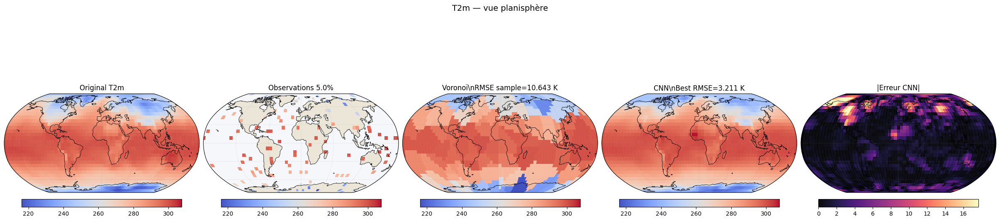

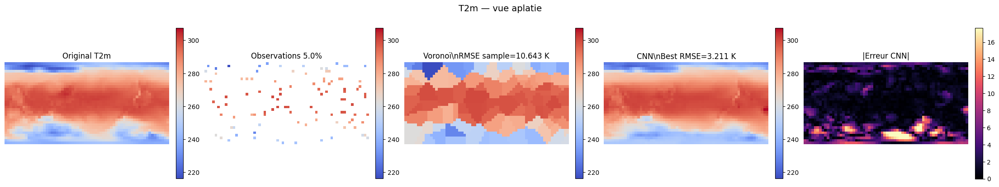

In [21]:
# ── A7. Visualisation ───────────────────────────────────────────────────────
plot_univariate_sample(
    model_uni,
    test_ds,
    idx=0,
    mu=mu,
    sigma=sigma,
    device=device,
    best_rmse=results_uni["rmse_global"],
    ds_geo=ds,
)

## 12. Multivariate StrongUNet

Reconstruct `z`, `q`, `t2m`, `u`, and `v` together.

### 12.1 Load multivariate fields

In [21]:
# ── B1. Chargement ─────────────────────────────────────────────────────────
print("Chargement ERA5 multivarié…")
# Réutiliser ds si déjà chargé en section A, sinon : ds = open_dataset()
fields = load_fields(ds, MULTIVAR_KEYS)
keys   = list(fields.keys())
print(f"Variables chargées : {keys}")

Chargement ERA5 multivarié…
[loader] z (geopotential): (2000, 32, 64)
[loader] q (specific_humidity): (2000, 32, 64)
[loader] t2m (2m_temperature): (2000, 32, 64)
[loader] u (10m_u_component_of_wind): (2000, 32, 64)
[loader] v (10m_v_component_of_wind): (2000, 32, 64)
Variables chargées : ['z', 'q', 't2m', 'u', 'v']


### 12.2 Split and normalize fields

In [22]:
# ── B2. Split + stats ───────────────────────────────────────────────────────
N = next(iter(fields.values())).shape[0]
idx_train_mv, idx_val_mv, idx_test_mv = compute_split_indices(N)
means, stds = compute_stats(fields, idx_train_mv)
CLIM_MV_MAPS_B = build_climatology_maps(fields, keys, idx_train_mv)
LAT_WEIGHTS_2D_B = get_lat_weights_2d(ds)
print(f"[B2] Climatologie multivariée prête: {list(CLIM_MV_MAPS_B.keys())}")


[loader] z: mu=13731.1328, sigma=1420.7734
[loader] q: mu=0.0046, sigma=0.0039
[loader] t2m: mu=278.1161, sigma=21.2220
[loader] u: mu=-0.0291, sigma=4.8813
[loader] v: mu=0.2188, sigma=4.1584
[B2] Climatologie multivariée prête: ['z', 'q', 't2m', 'u', 'v']


### 12.3 Build multivariate data loaders

In [23]:
# ── B3. Datasets & DataLoaders ──────────────────────────────────────────────
train_mv = MultiSparseVoronoiDataset(fields, keys, means, stds, idx_train_mv,
                                     keep_ratio=KEEP_RATIO, base_seed=SEED_TRAIN)
val_mv   = MultiSparseVoronoiDataset(fields, keys, means, stds, idx_val_mv,
                                     keep_ratio=KEEP_RATIO, base_seed=SEED_VAL)
test_mv  = MultiSparseVoronoiDataset(fields, keys, means, stds, idx_test_mv,
                                     keep_ratio=KEEP_RATIO, base_seed=SEED_TEST)

train_loader_mv = DataLoader(train_mv, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  num_workers=0)
val_loader_mv   = DataLoader(val_mv,   batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)
test_loader_mv  = DataLoader(test_mv,  batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)

x, y, m = train_mv[0]
print(f"x: {x.shape}, y: {y.shape}, m: {m.shape}")

x: torch.Size([15, 32, 64]), y: torch.Size([5, 32, 64]), m: torch.Size([5, 32, 64])


### 12.4 Initialize models

In [24]:
# ── B4. Modèles ─────────────────────────────────────────────────────────────
# Exécuter les deux modèles dans le même notebook
RUN_MODELS = ["fukami", "strongunet"]  # ordre d'exécution
USE_ADAPTIVE_WEIGHTS = False             # demandé: pas nécessaire d'ajuster les poids
FIXED_LOSS_WEIGHTS = None                # None -> uniformes ; sinon ex: MULTIVAR_WEIGHTS
if FIXED_LOSS_WEIGHTS is None:
    print("[B4] MULTIVAR_WEIGHTS défini mais non utilisé (FIXED_LOSS_WEIGHTS=None).")

K = len(keys)
models_to_run = {}
for name in RUN_MODELS:
    n = name.lower().strip()
    if n == "strongunet":
        models_to_run[n] = StrongUNet(in_ch=3 * K, out_ch=K, base=UNET_BASE, dropout=0.3).to(device)
    elif n == "fukami":
        models_to_run[n] = FukamiBaseline(in_ch=3 * K, out_ch=K, base=UNET_BASE, dropout=0.2).to(device)
    else:
        raise ValueError(f"Modèle inconnu: {name}")

for model_key, model_obj in models_to_run.items():
    n_params = sum(p.numel() for p in model_obj.parameters())
    print(f"{model_key} multivarié (K={K}) : {n_params:,} paramètres, device={device}")


[B4] MULTIVAR_WEIGHTS défini mais non utilisé (FIXED_LOSS_WEIGHTS=None).
fukami multivarié (K=5) : 1,686,981 paramètres, device=cuda
strongunet multivarié (K=5) : 8,339,635 paramètres, device=cuda


### 12.5 Train models

In [26]:
# ── B5. Entraînement (Fukami + StrongUNet) ─────────────────────────────────
trained_models = {}
results_by_model = {}
train_results_by_model = {}

for model_name, model in models_to_run.items():
    print(f"================ {model_name.upper()} ================")
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    if USE_ADAPTIVE_WEIGHTS:
        print("Entraînement adaptatif (poids mis à jour chaque époque)...")
        trained = train_model_adaptive(
            model, train_loader_mv, val_loader_mv, optimizer,
            keys=keys,
            device=device,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
        )
    else:
        print("Entraînement à poids fixes (pas d'ajustement adaptatif)...")
        trained = train_model_fixed_weights(
            model, train_loader_mv, val_loader_mv, optimizer,
            keys=keys,
            device=device,
            fixed_weights=FIXED_LOSS_WEIGHTS,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
        )

    trained_models[model_name] = trained

    # Évaluation test et train pour diagnostics
    results_by_model[model_name] = evaluate_multivariate(
        trained, test_loader_mv, keys, means, stds, device,
        climatology_maps=CLIM_MV_MAPS_B,
        lat_weights_2d=LAT_WEIGHTS_2D_B,
    )
    train_eval_loader = DataLoader(train_mv, batch_size=BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
    train_results_by_model[model_name] = evaluate_multivariate(
        trained, train_eval_loader, keys, means, stds, device,
        climatology_maps=CLIM_MV_MAPS_B,
        lat_weights_2d=LAT_WEIGHTS_2D_B,
    )


================ FUKAMI ================
Entraînement à poids fixes (pas d'ajustement adaptatif)...
[train_model_fixed_weights] Note: val_loss comparable intra-run uniquement; inter-run, comparer plutôt NRMSE/ACC/SSIM.
Epoch 01 | train=1.69071 | val=1.46845 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 02 | train=1.28232 | val=1.08827 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 03 | train=0.97693 | val=0.94747 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 04 | train=0.87215 | val=0.87611 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 05 | train=0.81132 | val=0.86194 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 06 | train=0.76680 | val=0.83867 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 07 | train=0.72892 | val=0.84186 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 08 | train=0.69588 | val=0.82620 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 

### 12.6 Evaluate models

In [27]:
# ── B6. Évaluation + écart train/test vents ─────────────────────────────────
for model_name in RUN_MODELS:
    mn = model_name.lower().strip()
    if mn not in results_by_model:
        continue
    results_mv = results_by_model[mn]
    train_results_mv = train_results_by_model[mn]

    print(f"── Résultats {mn.upper()} Multivarié ──")
    print(f"  {'Var':>4s} | {'RMSE global':>12s} | {'NRMSE global':>12s} | {'RMSE non-obs.':>13s} | {'NRMSE non-obs.':>14s} | {'ACC':>6s} | {'SSIM':>6s}")
    print("  " + "-" * 87)
    for k, v in results_mv.items():
        print(f"  {k:>4s} | {v['rmse_global']:>12.4f} | {v['nrmse_global']:>12.4f} | {v['rmse_unknown']:>13.4f} | {v['nrmse_unknown']:>14.4f} | {v['acc']:>6.4f} | {v['ssim']:>6.4f}")

    nrmse_global_mean  = float(np.mean([v['nrmse_global']  for v in results_mv.values()]))
    nrmse_unknown_mean = float(np.mean([v['nrmse_unknown'] for v in results_mv.values()]))
    acc_mv_mean        = float(np.nanmean([v['acc']        for v in results_mv.values()]))
    ssim_mv_mean       = float(np.mean([v['ssim']          for v in results_mv.values()]))
    print("  " + "-" * 87)
    print(f"  {'moy.':>4s} | {'':12} | {nrmse_global_mean:>12.4f} | {'':13} | {nrmse_unknown_mean:>14.4f} | {acc_mv_mean:>6.4f} | {ssim_mv_mean:>6.4f}")

    print("=== Écart train/test (vents) ===")
    print(f"  {'Var':>4s} | {'NRMSE train':>12s} | {'NRMSE test':>11s} | {'Gap test-train':>14s} | {'ACC train':>9s} | {'ACC test':>8s} | {'SSIM train':>10s} | {'SSIM test':>9s}")
    print("  " + "-" * 104)
    for k in ["u", "v"]:
        if k not in results_mv or k not in train_results_mv:
            continue
        n_tr = train_results_mv[k]["nrmse_global"]
        n_te = results_mv[k]["nrmse_global"]
        a_tr = train_results_mv[k]["acc"]
        a_te = results_mv[k]["acc"]
        s_tr = train_results_mv[k]["ssim"]
        s_te = results_mv[k]["ssim"]
        print(f"  {k:>4s} | {n_tr:>12.4f} | {n_te:>11.4f} | {n_te - n_tr:>+14.4f} | {a_tr:>9.4f} | {a_te:>8.4f} | {s_tr:>10.4f} | {s_te:>9.4f}")

# Alias pour compatibilité avec les cellules suivantes
results_mv = results_by_model.get('strongunet', next(iter(results_by_model.values())))
model_mv = trained_models.get('strongunet', next(iter(trained_models.values())))


── Résultats FUKAMI Multivarié ──
   Var |  RMSE global | NRMSE global | RMSE non-obs. | NRMSE non-obs. |    ACC |   SSIM
  ---------------------------------------------------------------------------------------
     z |     300.9510 |       0.2118 |      307.2872 |         0.2163 | 0.8593 | 0.8855
     q |       0.0011 |       0.2943 |        0.0012 |         0.2972 | 0.6540 | 0.7712
   t2m |       3.8521 |       0.1815 |        3.8792 |         0.1828 | 0.6899 | 0.9265
     u |       2.3719 |       0.4859 |        2.4277 |         0.4973 | 0.7426 | 0.6158
     v |       2.4429 |       0.5875 |        2.5051 |         0.6024 | 0.7450 | 0.5015
  ---------------------------------------------------------------------------------------
  moy. |              |       0.3522 |               |         0.3592 | 0.7381 | 0.7401
=== Écart train/test (vents) ===
   Var |  NRMSE train |  NRMSE test | Gap test-train | ACC train | ACC test | SSIM train | SSIM test
  ----------------------------------

Compare the univariate and multivariate temperature results.

### 12.7 Compare temperature results

In [28]:
# ── Comparaison A (Univarié) vs B (Multivarié) sur t2m ──────────────────────
u = results_uni

print("── Comparaison Univarié vs Multivarié (t2m) ──")
header = f"  {'Modèle':<16s} | {'RMSE global':>11s} | {'NRMSE global':>12s} | {'RMSE non-obs.':>13s} | {'NRMSE non-obs.':>14s} | {'ACC':>6s} | {'SSIM':>6s}"
sep = "  " + "-" * (len(header) - 2)
print(header)
print(sep)
print(f"  {'Univarié':<16s} | {u['rmse_global']:>11.4f} | {u['nrmse_global']:>12.4f} | {u['rmse_unknown']:>13.4f} | {u['nrmse_unknown']:>14.4f} | {u['acc']:>6.4f} | {u['ssim']:>6.4f}")

for model_name in RUN_MODELS:
    mn = model_name.lower().strip()
    if mn not in results_by_model:
        continue
    mv = results_by_model[mn]["t2m"]
    label = f"Multivarié-{mn}"
    print(f"  {label:<16s} | {mv['rmse_global']:>11.4f} | {mv['nrmse_global']:>12.4f} | {mv['rmse_unknown']:>13.4f} | {mv['nrmse_unknown']:>14.4f} | {mv['acc']:>6.4f} | {mv['ssim']:>6.4f}")
print(sep)


── Comparaison Univarié vs Multivarié (t2m) ──
  Modèle           | RMSE global | NRMSE global | RMSE non-obs. | NRMSE non-obs. |    ACC |   SSIM
  ------------------------------------------------------------------------------------------------
  Univarié         |      3.2107 |       0.1513 |        3.2656 |         0.1539 | 0.8067 | 0.9547
  Multivarié-fukami |      3.8521 |       0.1815 |        3.8792 |         0.1828 | 0.6899 | 0.9265
  Multivarié-strongunet |      3.1044 |       0.1463 |        3.1747 |         0.1496 | 0.7966 | 0.9436
  ------------------------------------------------------------------------------------------------


### 12.8 Plot multivariate results

Visualisation: FUKAMI


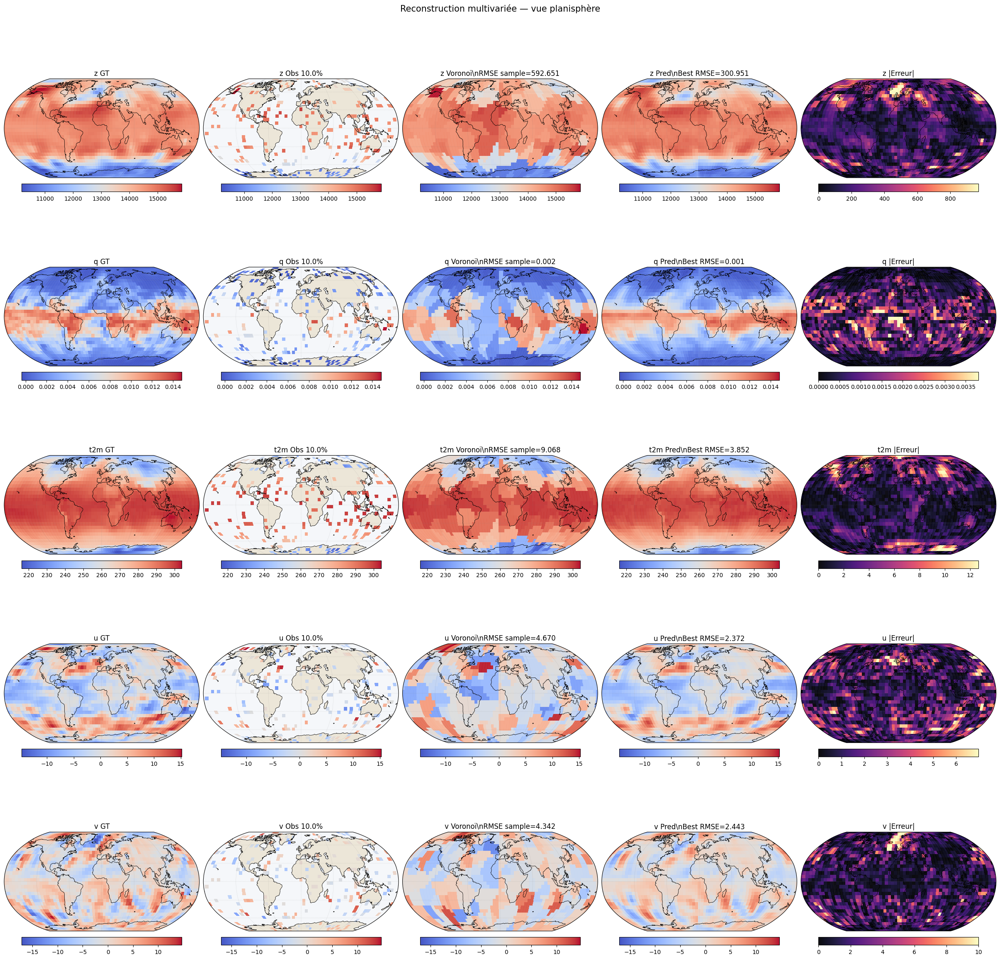

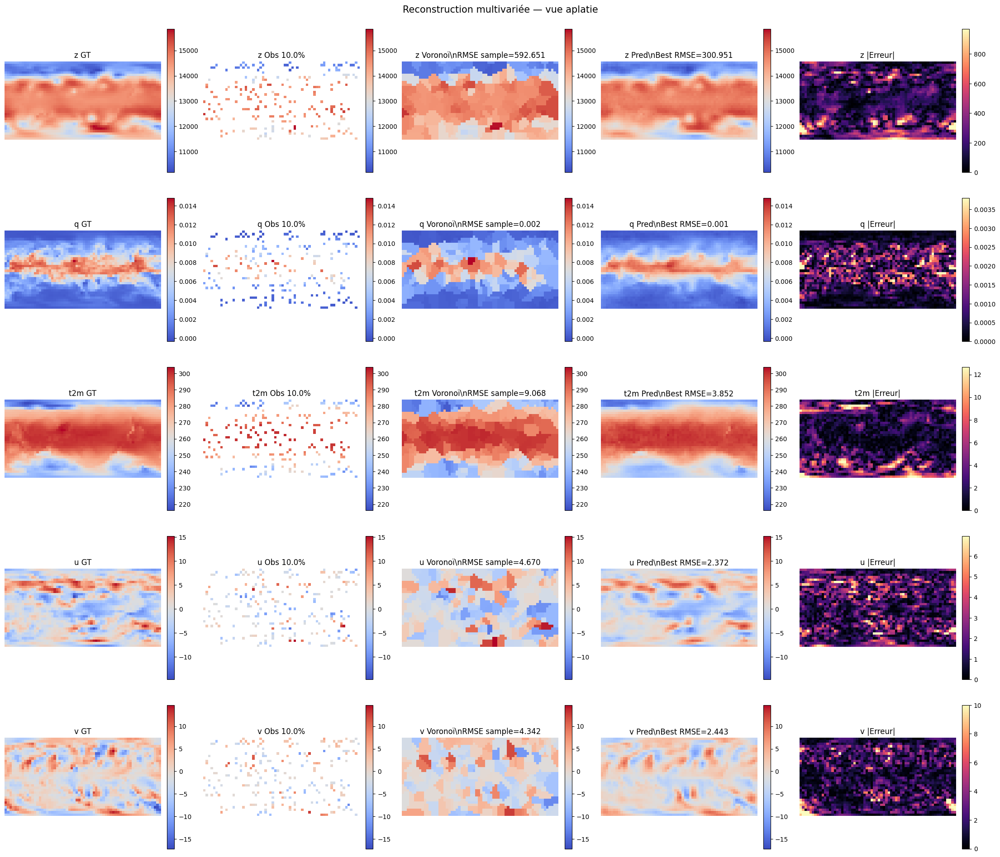

Visualisation: STRONGUNET


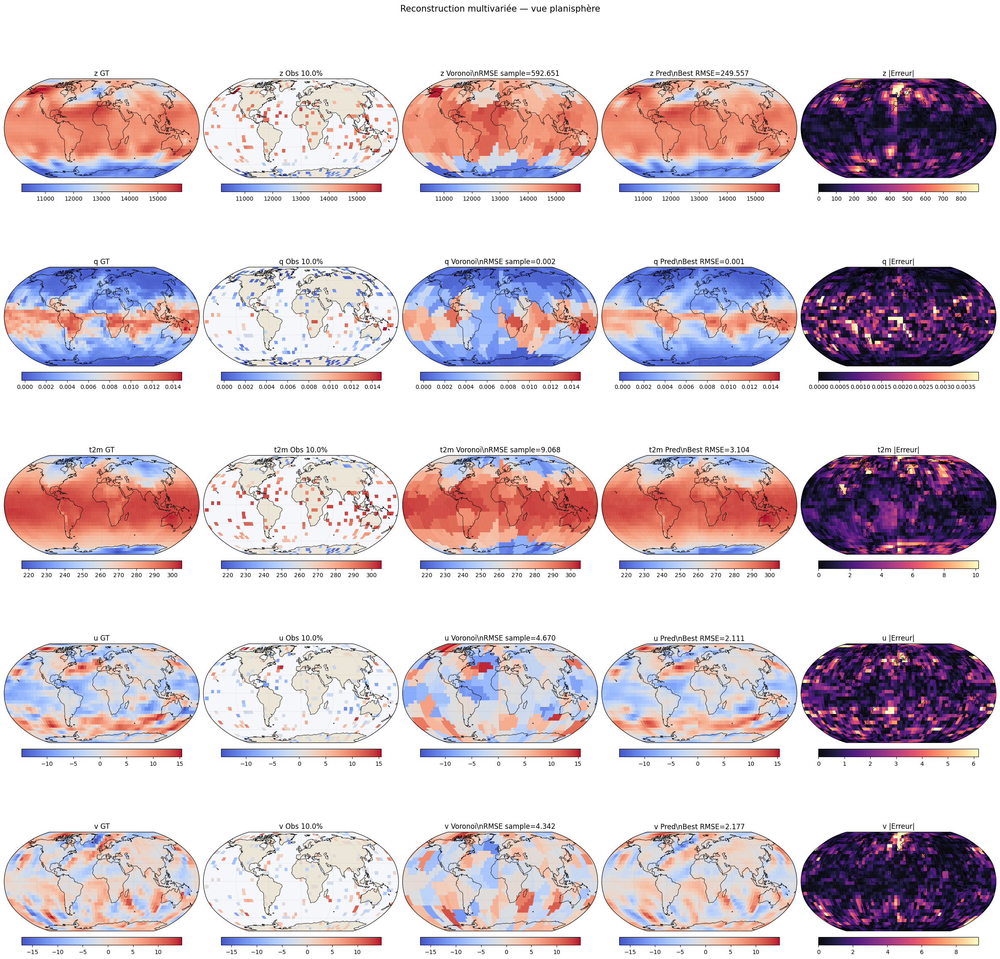

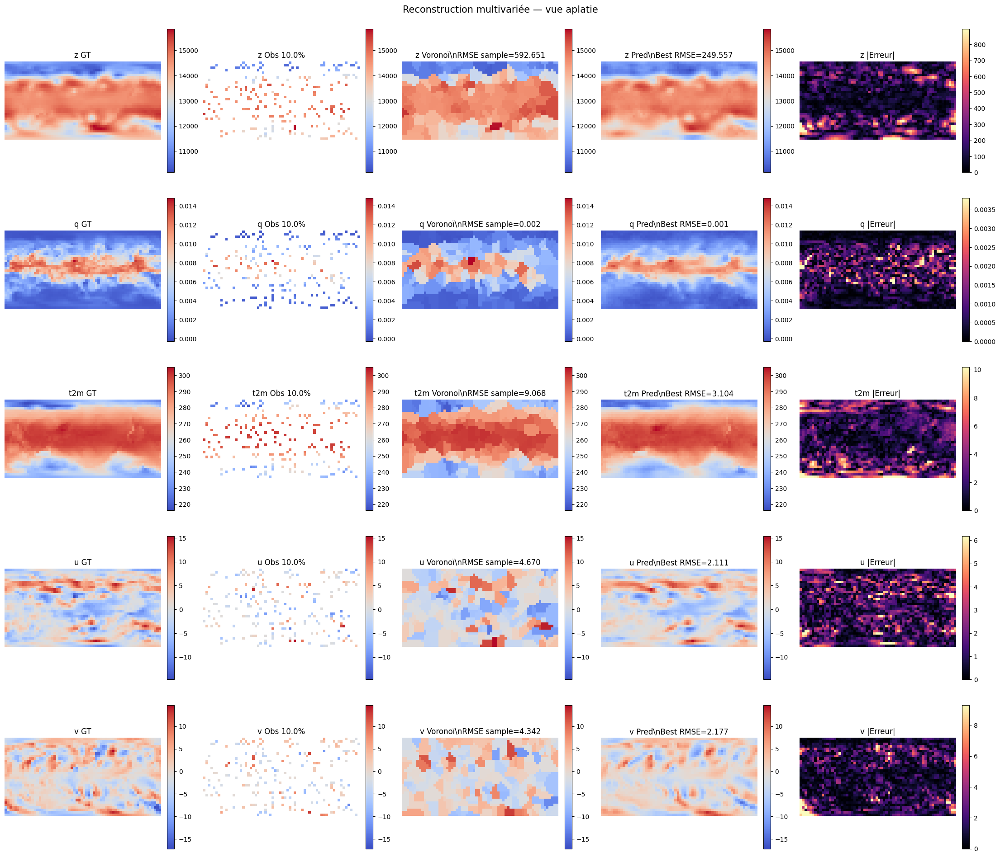

In [29]:
# ── B7. Visualisation ───────────────────────────────────────────────────────
# Visualisation d'un exemple pour chaque modèle exécuté
for model_name in RUN_MODELS:
    mn = model_name.lower().strip()
    if mn not in trained_models or mn not in results_by_model:
        continue
    print(f"Visualisation: {mn.upper()}")
    plot_multivariate_sample(
        trained_models[mn],
        test_mv,
        keys,
        means,
        stds,
        idx=0,
        device=device,
        best_rmse={k: results_by_model[mn][k]["rmse_global"] for k in keys},
        ds_geo=ds,
    )


## 13. Optional model export

### 13.1 Example model export

In [30]:
# torch.save(model_uni.state_dict(), "strongunet_uni.pt")
# torch.save(model_mv.state_dict(),  "strongunet_mv.pt")

# Rechargement :
# model_uni.load_state_dict(torch.load("strongunet_uni.pt", map_location=device))
# model_mv.load_state_dict(torch.load("strongunet_mv.pt",  map_location=device))

## 14. Sensor density study

Evaluate StrongUNet at 5%, 10%, and 15% observed cells.

### 14.1 Run sensor density sweep

[C1] Entraînement avec poids FIXES (non adaptatifs): [1.0, 1.0, 1.0, 1.0, 1.0]

=== StrongUNet multivarié | keep_ratio=5% ===
[train_model_fixed_weights] Note: val_loss comparable intra-run uniquement; inter-run, comparer plutôt NRMSE/ACC/SSIM.
Epoch 01 | train=1.26834 | val=1.00099 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 02 | train=0.93454 | val=0.92716 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 03 | train=0.87182 | val=0.90429 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 04 | train=0.83573 | val=0.88414 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 05 | train=0.80425 | val=0.88028 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 06 | train=0.77755 | val=0.88685 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 07 | train=0.75252 | val=0.90860 | poids fixes [z=1.00 | q=1.00 | t2m=1.00 | u=1.00 | v=1.00]
Epoch 08 | train=0.72895 | val=0.90993 | poids fixes [z

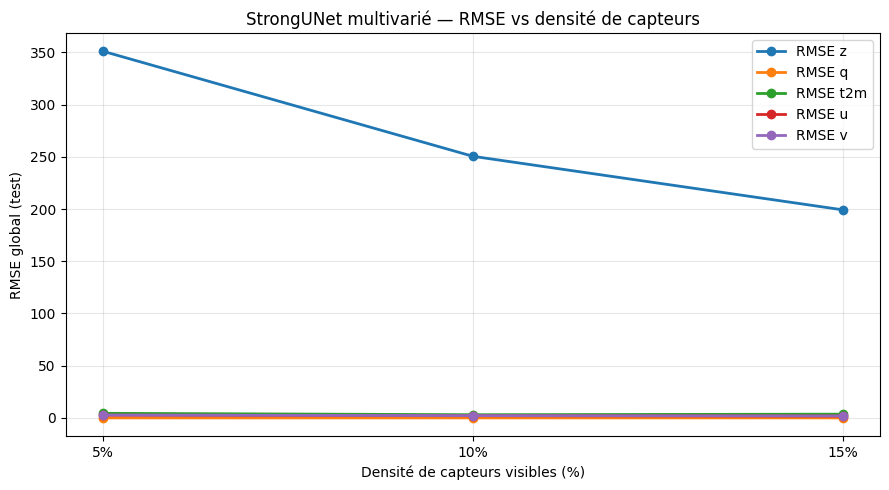

In [31]:
# ── C1. Sweep densité capteurs pour StrongUNet ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

KEEP_RATIOS = [0.05, 0.10, 0.15]

results_by_ratio = {}
models_by_ratio = {}

K = len(keys)

FIXED_SWEEP_WEIGHTS = [1.0] * K
print(f"[C1] Entraînement avec poids FIXES (non adaptatifs): {FIXED_SWEEP_WEIGHTS}")

for keep_ratio in KEEP_RATIOS:
    print(f"\n=== StrongUNet multivarié | keep_ratio={keep_ratio:.0%} ===")

    train_mv_r = MultiSparseVoronoiDataset(
        fields, keys, means, stds, idx_train_mv,
        keep_ratio=keep_ratio, base_seed=SEED_TRAIN
    )
    val_mv_r = MultiSparseVoronoiDataset(
        fields, keys, means, stds, idx_val_mv,
        keep_ratio=keep_ratio, base_seed=SEED_VAL
    )
    test_mv_r = MultiSparseVoronoiDataset(
        fields, keys, means, stds, idx_test_mv,
        keep_ratio=keep_ratio, base_seed=SEED_TEST
    )

    train_loader_r = DataLoader(train_mv_r, batch_size=BATCH_SIZE_TRAIN, shuffle=True,  num_workers=0)
    val_loader_r   = DataLoader(val_mv_r,   batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)
    test_loader_r  = DataLoader(test_mv_r,  batch_size=BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)

    model_r = StrongUNet(in_ch=3 * K, out_ch=K, base=UNET_BASE, dropout=0.3).to(device)
    optimizer_r = torch.optim.Adam(model_r.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    model_r = train_model_fixed_weights(
        model_r, train_loader_r, val_loader_r, optimizer_r,
        keys=keys,
        device=device,
        fixed_weights=FIXED_SWEEP_WEIGHTS,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    res_r = evaluate_multivariate(
        model_r, test_loader_r, keys, means, stds, device,
        climatology_maps=CLIM_MV_MAPS_B,
        lat_weights_2d=LAT_WEIGHTS_2D_B,
    )
    print_results_multivariate(res_r)

    models_by_ratio[keep_ratio] = model_r
    results_by_ratio[keep_ratio] = res_r


# ── C2. Résumé chiffré (RMSE / NRMSE / ACC / SSIM) ─────────────────────────
print("\n=== Résumé StrongUNet par densité ===")
header = f"{'Ratio':>6s} | {'Var':>4s} | {'RMSE':>10s} | {'NRMSE':>10s} | {'ACC':>8s} | {'SSIM':>8s}"
print(header)
print('-' * len(header))
for r in KEEP_RATIOS:
    for k in keys:
        v = results_by_ratio[r][k]
        print(f"{r:>6.2f} | {k:>4s} | {v['rmse_global']:>10.4f} | {v['nrmse_global']:>10.4f} | {v['acc']:>8.4f} | {v['ssim']:>8.4f}")


# ── C3. Courbe RMSE en fonction de la densité ───────────────────────────────
x = [r * 100 for r in KEEP_RATIOS]

plt.figure(figsize=(9, 5))
for k in keys:
    y = [results_by_ratio[r][k]['rmse_global'] for r in KEEP_RATIOS]
    plt.plot(x, y, marker='o', linewidth=2, label=f'RMSE {k}')

plt.xlabel('Densité de capteurs visibles (%)')
plt.ylabel('RMSE global (test)')
plt.title('StrongUNet multivarié — RMSE vs densité de capteurs')
plt.grid(True, alpha=0.3)
plt.xticks(x, [f"{int(v)}%" for v in x])
plt.legend()
plt.tight_layout()
plt.show()





Compare normalized RMSE by variable and its mean.

### 14.2 Plot normalized RMSE

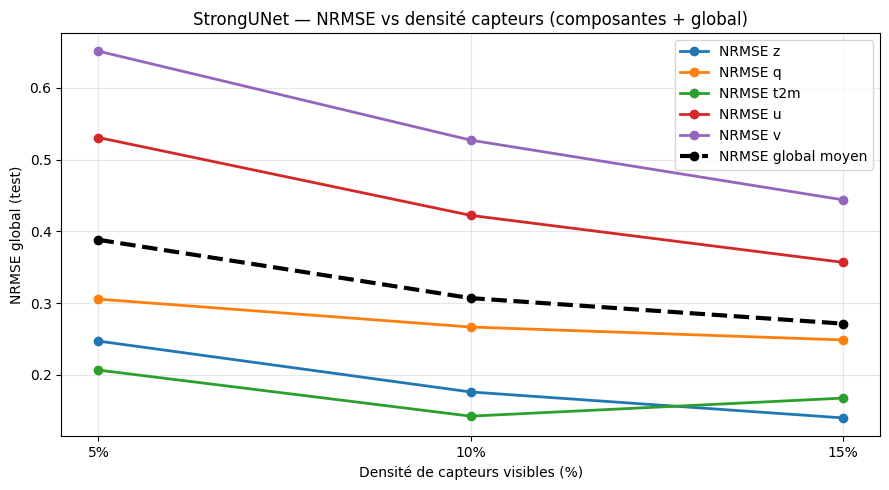

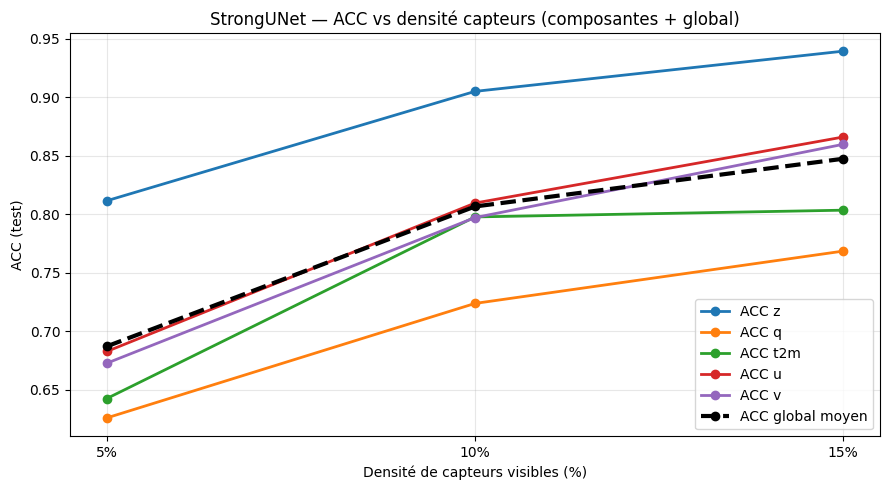

In [32]:
# ── C4. NRMSE sur un seul graphique (composantes + global) ──────────────────
import matplotlib.pyplot as plt

if 'results_by_ratio' not in globals() or len(results_by_ratio) == 0:
    raise RuntimeError("results_by_ratio est vide. Exécute d'abord la cellule C1/C2.")

x = [r * 100 for r in KEEP_RATIOS]
xt = [f"{int(v)}%" for v in x]

plt.figure(figsize=(9, 5))

# NRMSE par composante
for k in keys:
    y = [results_by_ratio[r][k]['nrmse_global'] for r in KEEP_RATIOS]
    plt.plot(x, y, marker='o', linewidth=2, label=f"NRMSE {k}")

# NRMSE global moyen
global_nrmse = [
    sum(results_by_ratio[r][k]['nrmse_global'] for k in keys) / len(keys)
    for r in KEEP_RATIOS
]
plt.plot(x, global_nrmse, marker='o', linewidth=3, color='black', linestyle='--', label='NRMSE global moyen')

plt.title("StrongUNet — NRMSE vs densité capteurs (composantes + global)")
plt.xlabel("Densité de capteurs visibles (%)")
plt.ylabel("NRMSE global (test)")
plt.xticks(x, xt)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ── C5. ACC sur un seul graphique (composantes + global) ────────────────────
plt.figure(figsize=(9, 5))

for k in keys:
    y = [results_by_ratio[r][k]['acc'] for r in KEEP_RATIOS]
    plt.plot(x, y, marker='o', linewidth=2, label=f"ACC {k}")

global_acc = [
    float(np.nanmean([results_by_ratio[r][k]['acc'] for k in keys]))
    for r in KEEP_RATIOS
]
plt.plot(x, global_acc, marker='o', linewidth=3, color='black', linestyle='--', label='ACC global moyen')

plt.title("StrongUNet — ACC vs densité capteurs (composantes + global)")
plt.xlabel("Densité de capteurs visibles (%)")
plt.ylabel("ACC (test)")
plt.xticks(x, xt)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



### 14.3 Test across sensor densities

keep_ratio=5% | NRMSE=0.3894 | ACC=0.6923 | SSIM=0.7049
keep_ratio=6% | NRMSE=0.3646 | ACC=0.7313 | SSIM=0.7267
keep_ratio=7% | NRMSE=0.3457 | ACC=0.7573 | SSIM=0.7429
keep_ratio=8% | NRMSE=0.3306 | ACC=0.7774 | SSIM=0.7580
keep_ratio=9% | NRMSE=0.3183 | ACC=0.7933 | SSIM=0.7701
keep_ratio=10% | NRMSE=0.3071 | ACC=0.8067 | SSIM=0.7799
keep_ratio=11% | NRMSE=0.2980 | ACC=0.8175 | SSIM=0.7896
keep_ratio=12% | NRMSE=0.2892 | ACC=0.8271 | SSIM=0.7971
keep_ratio=13% | NRMSE=0.2810 | ACC=0.8358 | SSIM=0.8050
keep_ratio=14% | NRMSE=0.2749 | ACC=0.8423 | SSIM=0.8108
keep_ratio=15% | NRMSE=0.2689 | ACC=0.8485 | SSIM=0.8157
keep_ratio=16% | NRMSE=0.2633 | ACC=0.8538 | SSIM=0.8211
keep_ratio=17% | NRMSE=0.2581 | ACC=0.8589 | SSIM=0.8254
keep_ratio=18% | NRMSE=0.2540 | ACC=0.8634 | SSIM=0.8299
keep_ratio=19% | NRMSE=0.2492 | ACC=0.8674 | SSIM=0.8342
keep_ratio=20% | NRMSE=0.2451 | ACC=0.8714 | SSIM=0.8370
keep_ratio=21% | NRMSE=0.2423 | ACC=0.8740 | SSIM=0.8398
keep_ratio=22% | NRMSE=0.2389 | ACC=

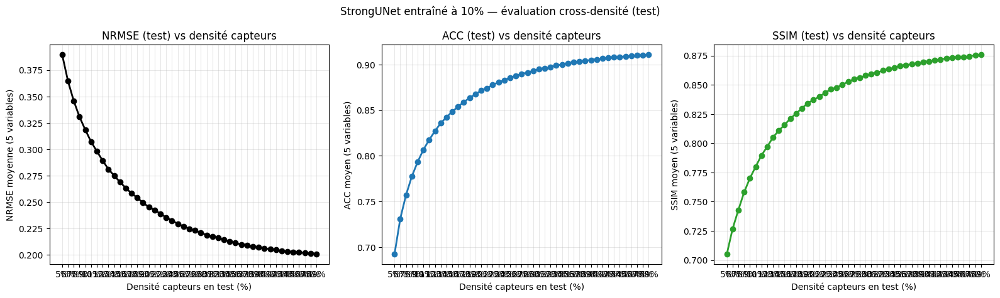

In [33]:
# ── C5. Modèle entraîné à 10% -> éval test de 5% à 25% ─────────────────────
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

EVAL_KEEP_RATIOS = [r / 100 for r in range(5, 50)]
TRAIN_RATIO_REF = 0.10

if 'models_by_ratio' not in globals() or len(models_by_ratio) == 0:
    raise RuntimeError("models_by_ratio introuvable. Exécute d'abord C1.")

required = ['fields', 'keys', 'means', 'stds', 'idx_test_mv', 'SEED_TEST', 'device']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Contexte manquant pour C5: {missing}. Exécute B puis C1.")

# Récupère la clé la plus proche de 0.10 (robuste au float)
model_key = min(models_by_ratio.keys(), key=lambda k: abs(float(k) - TRAIN_RATIO_REF))
if abs(float(model_key) - TRAIN_RATIO_REF) > 1e-9:
    raise RuntimeError(f"Pas de modèle 10% dans models_by_ratio. Clés dispo: {list(models_by_ratio.keys())}")

model_ref_10 = models_by_ratio[model_key]

c5_metrics = {'nrmse': [], 'acc': [], 'ssim': []}

for keep_ratio_eval in EVAL_KEEP_RATIOS:
    test_mv_eval = MultiSparseVoronoiDataset(
        fields, keys, means, stds, idx_test_mv,
        keep_ratio=keep_ratio_eval, base_seed=SEED_TEST
    )
    test_loader_eval = DataLoader(
        test_mv_eval,
        batch_size=BATCH_SIZE_EVAL,
        shuffle=False,
        num_workers=0,
    )

    res_eval = evaluate_multivariate(
        model_ref_10, test_loader_eval, keys, means, stds, device,
        climatology_maps=CLIM_MV_MAPS_B,
        lat_weights_2d=LAT_WEIGHTS_2D_B,
    )

    nrmse_mean = float(np.mean([res_eval[k]['nrmse_global'] for k in keys]))
    acc_mean   = float(np.mean([res_eval[k]['acc'] for k in keys]))
    ssim_mean  = float(np.mean([res_eval[k]['ssim'] for k in keys]))

    c5_metrics['nrmse'].append(nrmse_mean)
    c5_metrics['acc'].append(acc_mean)
    c5_metrics['ssim'].append(ssim_mean)

    print(f"keep_ratio={keep_ratio_eval:.0%} | NRMSE={nrmse_mean:.4f} | ACC={acc_mean:.4f} | SSIM={ssim_mean:.4f}")

x = [100 * r for r in EVAL_KEEP_RATIOS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(x, c5_metrics['nrmse'], marker='o', linewidth=2, color='black')
axes[0].set_title('NRMSE (test) vs densité capteurs')
axes[0].set_xlabel('Densité capteurs en test (%)')
axes[0].set_ylabel('NRMSE moyenne (5 variables)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, c5_metrics['acc'], marker='o', linewidth=2, color='tab:blue')
axes[1].set_title('ACC (test) vs densité capteurs')
axes[1].set_xlabel('Densité capteurs en test (%)')
axes[1].set_ylabel('ACC moyen (5 variables)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, c5_metrics['ssim'], marker='o', linewidth=2, color='tab:green')
axes[2].set_title('SSIM (test) vs densité capteurs')
axes[2].set_xlabel('Densité capteurs en test (%)')
axes[2].set_ylabel('SSIM moyen (5 variables)')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(v)}%" for v in x])

plt.suptitle('StrongUNet entraîné à 10% — évaluation cross-densité (test)')
plt.tight_layout()
plt.show()


## 15. Changing training masks across epochs

Use 4,000 samples, 10% observed cells, fixed variable weights, and reproducible masks that change between epochs.

### 15.1 Train with changing masks

In [25]:
# ── F1. Setup autonome (copie de E) + F2/F3 (dataset epoch-aware + entraînement) ──
import io
import re
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import redirect_stdout
from torch.utils.data import DataLoader, Dataset

F_N_TARGET         = 4000
F_TIME_SLICE       = slice(0, 4000)
F_KEEP_RATIO       = 0.10
F_UNET_BASE        = 64
F_BATCH_SIZE_TRAIN = 8
F_BATCH_SIZE_EVAL  = BATCH_SIZE_EVAL if 'BATCH_SIZE_EVAL' in globals() else 32
F_MAX_EPOCHS       = MAX_EPOCHS if 'MAX_EPOCHS' in globals() else 30
F_PATIENCE         = PATIENCE if 'PATIENCE' in globals() else 5
F_EPOCH_SEED_STRIDE = 1_000_003

print('[F1] Config F:')
print(f'  N_target={F_N_TARGET} | time_slice={F_TIME_SLICE}')
print(f'  keep_ratio={F_KEEP_RATIO:.0%} | base={F_UNET_BASE}')
print(f'  batch_train={F_BATCH_SIZE_TRAIN} | batch_eval={F_BATCH_SIZE_EVAL}')
print(f'  max_epochs={F_MAX_EPOCHS} | patience={F_PATIENCE}')
print(f'  epoch_seed_stride={F_EPOCH_SEED_STRIDE}')

# Source de vérité des poids fixes: section B
if 'FIXED_LOSS_WEIGHTS' not in globals():
    raise RuntimeError("FIXED_LOSS_WEIGHTS introuvable. Exécute d'abord la section B (poids fixes).")

print(f"[F1] FIXED_LOSS_WEIGHTS (source B) = {FIXED_LOSS_WEIGHTS}")

# Dépendances utilitaires
required_f = ['open_dataset', 'to_THW', 'compute_split_indices', 'compute_stats',
              'make_sparse_mask', 'voronoi_fill_from_sparse', 'StrongUNet', 'loss_fn_mv']
missing_f = [name for name in required_f if name not in globals()]
if missing_f:
    raise RuntimeError(f'Utilitaires manquants pour F: {missing_f}')

if 'MULTIVAR_KEYS' not in globals() or 'VAR_CANDIDATES' not in globals():
    raise RuntimeError('MULTIVAR_KEYS / VAR_CANDIDATES introuvables. Exécute les cellules de config en amont.')

print('[F1] Chargement ERA5 local pour section F...')
ds_f = open_dataset()

ref_var_f = next((v for v in ['2m_temperature', 't2m'] if v in ds_f.data_vars), None)
if ref_var_f is None:
    raise RuntimeError('Variable de référence temporelle introuvable dans ds_f (2m_temperature/t2m).')

time_size_f = int(ds_f[ref_var_f].time.size)
if time_size_f < F_N_TARGET:
    raise RuntimeError(
        f"Section F exige {F_N_TARGET} points, mais dataset n'en contient que {time_size_f}."
    )


def load_fields_with_slice_f(ds, keys, time_slice):
    out = {}
    for k in keys:
        candidates = VAR_CANDIDATES[k]
        vname = next((c for c in candidates if c in ds.data_vars), None)
        if vname is None:
            print(f"[F1] Variable '{k}' introuvable, ignorée.")
            continue
        out[k] = to_THW(ds[vname], time_slice=time_slice)
        print(f"[F1] {k} ({vname}): {out[k].shape}")
    return out

fields_f = load_fields_with_slice_f(ds_f, MULTIVAR_KEYS, F_TIME_SLICE)
keys_f = list(fields_f.keys())
if len(keys_f) == 0:
    raise RuntimeError('Aucune variable multivariée chargée pour F.')

N_f = next(iter(fields_f.values())).shape[0]
if N_f != F_N_TARGET:
    raise RuntimeError(f'Volume F inattendu: N_f={N_f}, attendu={F_N_TARGET}.')

idx_train_f, idx_val_f, idx_test_f = compute_split_indices(N_f)
means_f, stds_f = compute_stats(fields_f, idx_train_f)
CLIM_MV_MAPS_F = build_climatology_maps(fields_f, keys_f, idx_train_f)
LAT_WEIGHTS_2D_F = get_lat_weights_2d(ds_f)

print(f'[F1] N_f={N_f} | split train={len(idx_train_f)}, val={len(idx_val_f)}, test={len(idx_test_f)}')


# ── F2. Dataset train epoch-aware (masque variable par epoch, seed déterministe) ──
class MultiSparseVoronoiDatasetEpochMask(Dataset):
    def __init__(self, fields, keys, means, stds, indices, keep_ratio=0.10,
                 base_seed=0, different_masks=False, vary_with_epoch=True,
                 epoch_seed_stride=1_000_003):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.indices = np.array(indices, dtype=int)
        self.keep_ratio = float(keep_ratio)
        self.base_seed = int(base_seed)
        self.different_masks = bool(different_masks)
        self.vary_with_epoch = bool(vary_with_epoch)
        self.epoch_seed_stride = int(epoch_seed_stride)
        self.current_epoch = 0

        any_key = self.keys[0]
        _, self.H, self.W = self.fields[any_key].shape

    def set_epoch(self, epoch: int):
        self.current_epoch = int(epoch)

    def __len__(self):
        return len(self.indices)

    def _seed_shared(self, t: int) -> int:
        seed = self.base_seed + t
        if self.vary_with_epoch:
            seed += self.current_epoch * self.epoch_seed_stride
        return int(seed)

    def _seed_per_var(self, t: int, vi: int) -> int:
        seed = self.base_seed + t * 1000 + vi
        if self.vary_with_epoch:
            seed += self.current_epoch * self.epoch_seed_stride
        return int(seed)

    def __getitem__(self, i: int):
        t = int(self.indices[i])

        rng_main = np.random.default_rng(self._seed_shared(t))
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch, y_ch, m_ch = [], [], []
        for vi, k in enumerate(self.keys):
            field = self.fields[k][t]
            mu, sig = self.means[k], self.stds[k]

            if self.different_masks:
                rng_k = np.random.default_rng(self._seed_per_var(t, vi))
                mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask

            vor = voronoi_fill_from_sparse(field, mask)
            sparse = field * mask

            x_ch += [
                ((vor - mu) / sig).astype(np.float32),
                mask.astype(np.float32),
                ((sparse - mu) / sig).astype(np.float32),
            ]
            y_ch.append(((field - mu) / sig).astype(np.float32))
            m_ch.append(mask.astype(np.float32))

        x = torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32)
        y = torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32)
        m = torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32)
        return x, y, m


# ── F3. Datasets / modèle / entraînement (poids fixes comme B) ─────────────
train_ds_f = MultiSparseVoronoiDatasetEpochMask(
    fields_f, keys_f, means_f, stds_f, idx_train_f,
    keep_ratio=F_KEEP_RATIO,
    base_seed=SEED_TRAIN,
    different_masks=False,
    vary_with_epoch=True,
    epoch_seed_stride=F_EPOCH_SEED_STRIDE,
)

# Eval fixe: mêmes masques pour une carte donnée
val_ds_f = MultiSparseVoronoiDataset(
    fields_f, keys_f, means_f, stds_f, idx_val_f,
    keep_ratio=F_KEEP_RATIO, base_seed=SEED_VAL
)
test_ds_f = MultiSparseVoronoiDataset(
    fields_f, keys_f, means_f, stds_f, idx_test_f,
    keep_ratio=F_KEEP_RATIO, base_seed=SEED_TEST
)

train_loader_f = DataLoader(train_ds_f, batch_size=F_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
val_loader_f   = DataLoader(val_ds_f,   batch_size=F_BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)
test_loader_f  = DataLoader(test_ds_f,  batch_size=F_BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)

K_f = len(keys_f)
model_f = StrongUNet(in_ch=3 * K_f, out_ch=K_f, base=F_UNET_BASE, dropout=0.3).to(device)
optimizer_f = torch.optim.Adam(model_f.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params_f = sum(p.numel() for p in model_f.parameters() if p.requires_grad)
print(f'[F3] StrongUNet F: K={K_f}, params={n_params_f:,}, base={F_UNET_BASE}, device={device}')

if FIXED_LOSS_WEIGHTS is None:
    resolved_fixed_weights_f = [1.0] * K_f
else:
    if len(FIXED_LOSS_WEIGHTS) != K_f:
        raise RuntimeError(
            f'Incompatibilité poids fixes B: len(FIXED_LOSS_WEIGHTS)={len(FIXED_LOSS_WEIGHTS)} vs K_f={K_f}'
        )
    resolved_fixed_weights_f = [float(w) for w in FIXED_LOSS_WEIGHTS]

print(f'[F3] fixed_weights source(B)={FIXED_LOSS_WEIGHTS} | résolu(F)={resolved_fixed_weights_f}')
print(f'[F3] Loss coeffs globaux: WEIGHT_UNKNOWN={WEIGHT_UNKNOWN}, WEIGHT_ALL={WEIGHT_ALL}, LAMBDA_GRAD={LAMBDA_GRAD}')


def train_model_fixed_weights_f(model, train_loader, val_loader, optimizer, keys,
                                device, fixed_weights=None,
                                max_epochs=30, patience=5):
    """Section F: même logique que B, mais masques train mis à jour à chaque epoch."""
    K = len(keys)
    if fixed_weights is None:
        weights = [1.0] * K
    else:
        if len(fixed_weights) != K:
            raise ValueError(f"fixed_weights doit avoir longueur {K}, reçu {len(fixed_weights)}")
        weights = [float(w) for w in fixed_weights]

    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        if hasattr(train_loader.dataset, 'set_epoch'):
            train_loader.dataset.set_epoch(epoch)

        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_mv(model(x), y, m, weights, device).item())

        tr_mean = float(np.mean(tr_losses))
        va_mean = float(np.mean(va_losses))
        w_str = ' | '.join(f"{k}={weights[i]:.2f}" for i, k in enumerate(keys))
        print(
            f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f} | "
            f"poids fixes [{w_str}] | mask_epoch={epoch}",
            flush=True,
        )

        if va_mean < best_val - 1e-5:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


# Entraînement F (poids fixes B + masque train variable par epoch)
_f_stdout = io.StringIO()
with redirect_stdout(_f_stdout):
    model_f = train_model_fixed_weights_f(
        model_f,
        train_loader_f,
        val_loader_f,
        optimizer_f,
        keys=keys_f,
        device=device,
        fixed_weights=FIXED_LOSS_WEIGHTS,
        max_epochs=F_MAX_EPOCHS,
        patience=F_PATIENCE,
    )

f_train_log = _f_stdout.getvalue()
print(f_train_log, end='')

hist_f = {'epoch': [], 'train_loss': [], 'val_loss': []}
for m in re.finditer(r"Epoch\s+(\d+)\s+\|\s+train=([0-9]*\.?[0-9]+)\s+\|\s+val=([0-9]*\.?[0-9]+)", f_train_log):
    hist_f['epoch'].append(int(m.group(1)))
    hist_f['train_loss'].append(float(m.group(2)))
    hist_f['val_loss'].append(float(m.group(3)))

print(f"[F3] train_model_fixed_weights_f appelé: oui | epochs parsées={len(hist_f['epoch'])}")

F_CHECKPOINT_DIR = Path('checkpoints/reconstruction')
F_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
F_CHECKPOINT_PATH = F_CHECKPOINT_DIR / 'strongunet_f_epoch_mask.pt'
torch.save({
    'model_state_dict': model_f.state_dict(),
    'keys': keys_f,
    'means': means_f,
    'stds': stds_f,
    'keep_ratio': F_KEEP_RATIO,
    'time_slice': (F_TIME_SLICE.start, F_TIME_SLICE.stop, F_TIME_SLICE.step),
    'base': F_UNET_BASE,
}, F_CHECKPOINT_PATH)
print(f'[F3] Checkpoint F sauvegardé: {F_CHECKPOINT_PATH}')


[F1] Config F:
  N_target=4000 | time_slice=slice(0, 4000, None)
  keep_ratio=10% | base=64
  batch_train=8 | batch_eval=32
  max_epochs=30 | patience=5
  epoch_seed_stride=1000003
[F1] FIXED_LOSS_WEIGHTS (source B) = None
[F1] Chargement ERA5 local pour section F...
[F1] z (geopotential): (4000, 32, 64)
[F1] q (specific_humidity): (4000, 32, 64)
[F1] t2m (2m_temperature): (4000, 32, 64)
[F1] u (10m_u_component_of_wind): (4000, 32, 64)
[F1] v (10m_v_component_of_wind): (4000, 32, 64)
[loader] z: mu=13742.5244, sigma=1421.1805
[loader] q: mu=0.0045, sigma=0.0039
[loader] t2m: mu=278.0344, sigma=21.3680
[loader] u: mu=-0.0598, sigma=4.8730
[loader] v: mu=0.1973, sigma=4.1407
[F1] N_f=4000 | split train=2800, val=600, test=600
[F3] StrongUNet F: K=5, params=8,339,635, base=64, device=cuda
[F3] fixed_weights source(B)=None | résolu(F)=[1.0, 1.0, 1.0, 1.0, 1.0]
[F3] Loss coeffs globaux: WEIGHT_UNKNOWN=0.8, WEIGHT_ALL=0.2, LAMBDA_GRAD=2.5
Epoch 01 | train=0.85165 | val=0.70109 | poids fixes 

### 15.2 Evaluate changing-mask experiment

── Résultats Section F (masque train variable/epoch) ──
\n── Résultats multivarié ──────────────────────────────────────────────────────────────────
   Var |  RMSE global | NRMSE global | RMSE non-obs. | NRMSE non-obs. |    ACC |   SSIM
  ---------------------------------------------------------------------------------------
     z |     214.8081 |       0.1511 |      223.5110 |         0.1573 | 0.9329 | 0.9353
     q |       0.0010 |       0.2573 |        0.0010 |         0.2701 | 0.8095 | 0.8130
   t2m |       2.4197 |       0.1132 |        2.4853 |         0.1163 | 0.9152 | 0.9525
     u |       1.8912 |       0.3881 |        1.9858 |         0.4075 | 0.8527 | 0.7461
     v |       1.9978 |       0.4825 |        2.0991 |         0.5069 | 0.8441 | 0.6567
  ---------------------------------------------------------------------------------------
  moy. |              |       0.2785 |               |         0.2916 | 0.8709 | 0.8207
[F4] Moyennes F:
  NRMSE global moyen : 0.2785
  ACC mo

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


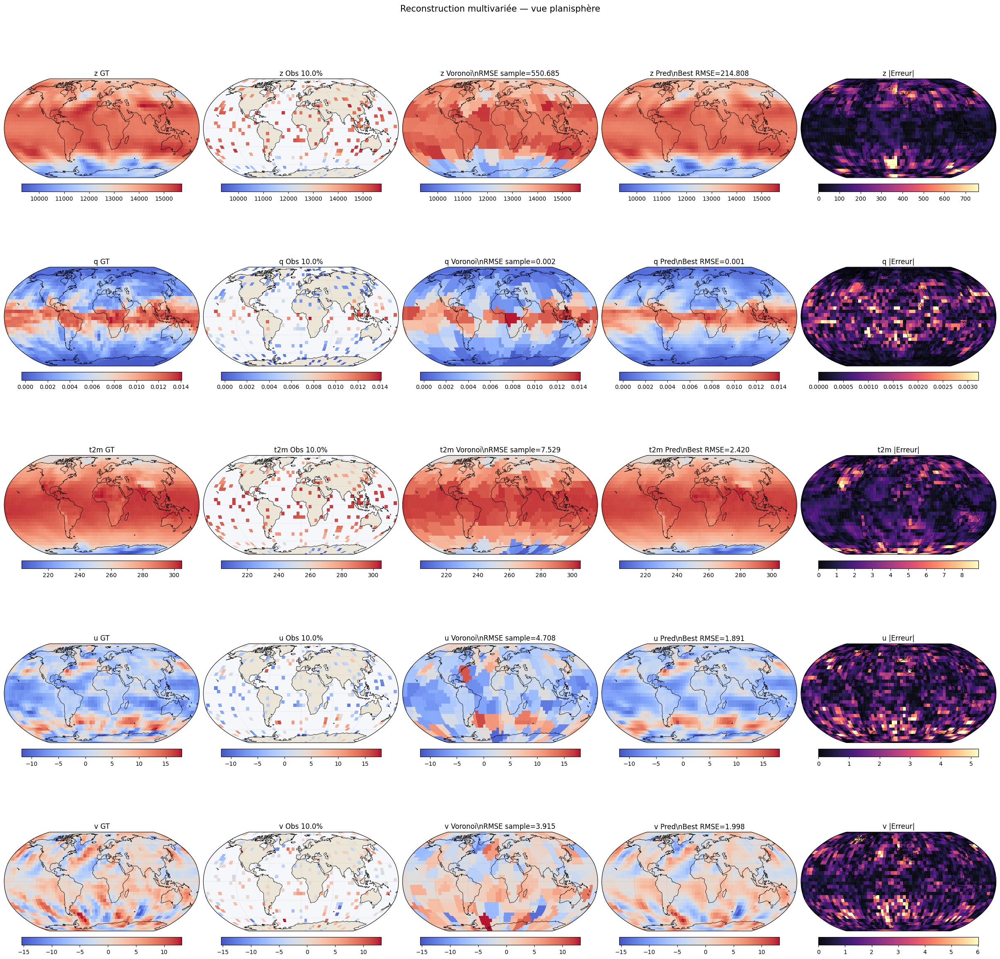

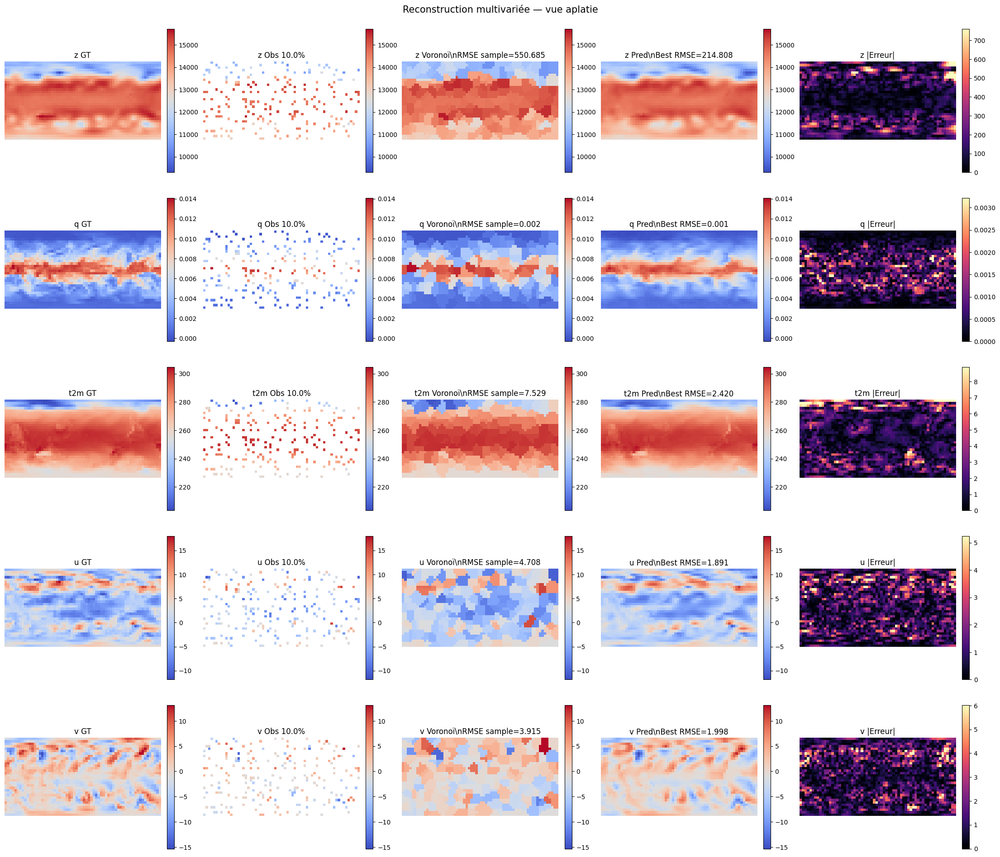

[F4] Visualisation sample test idx=1


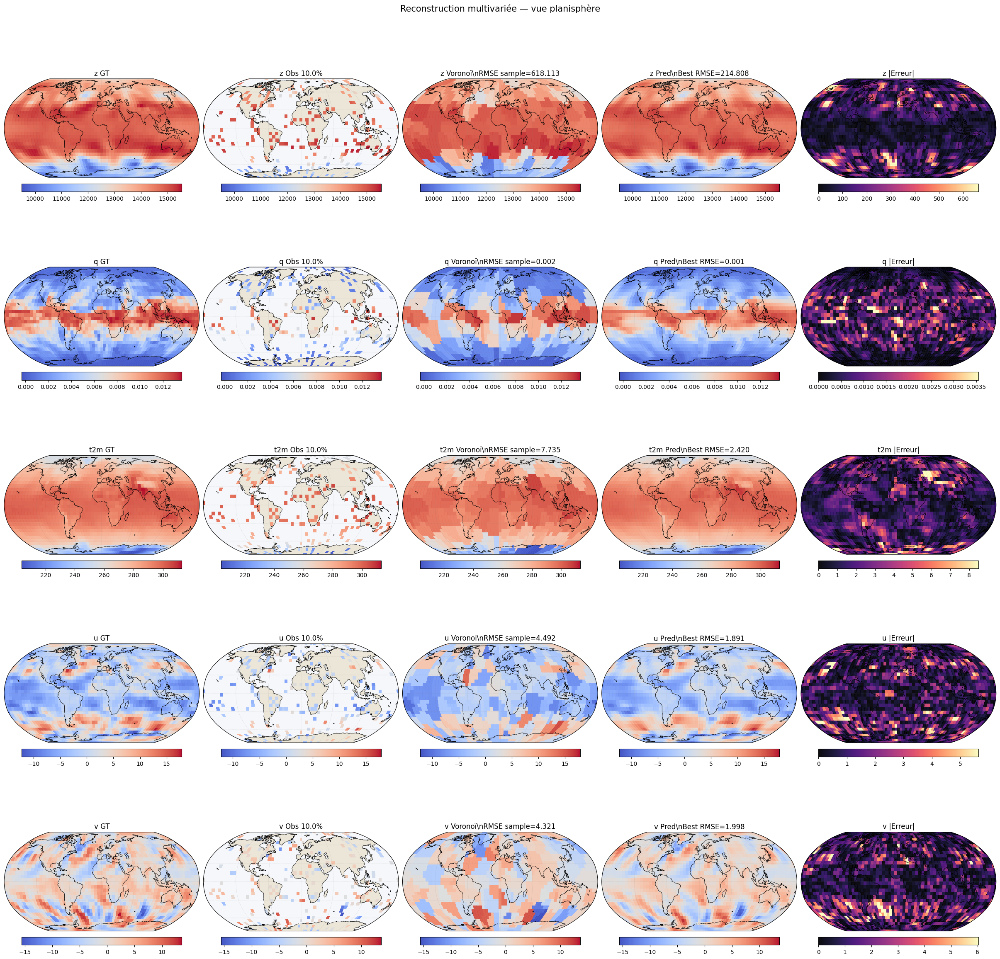

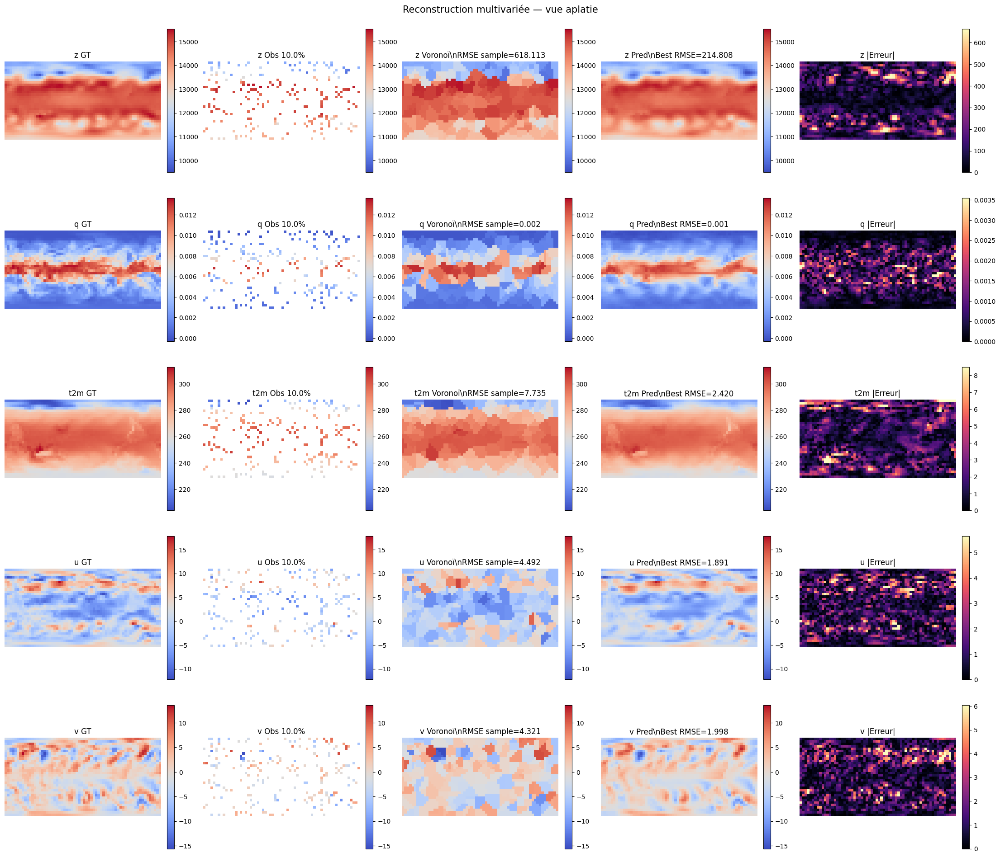

[F4] Visualisation sample test idx=2


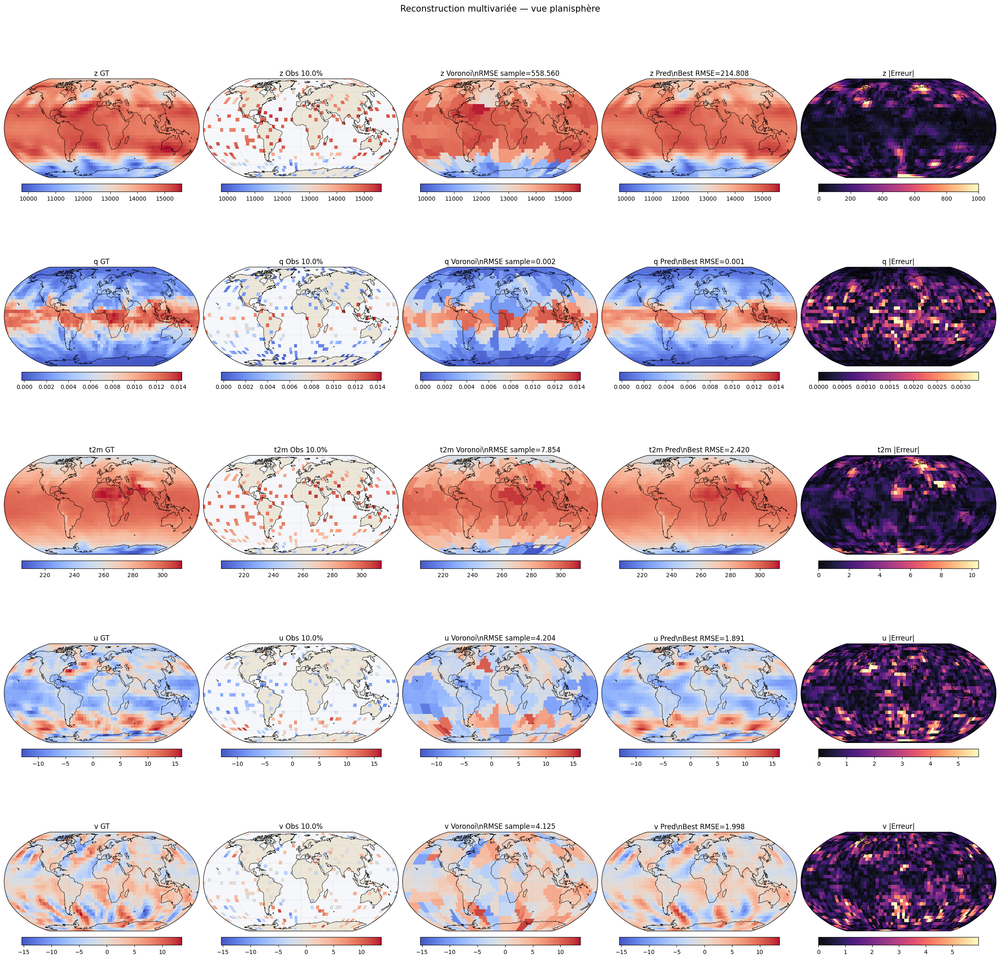

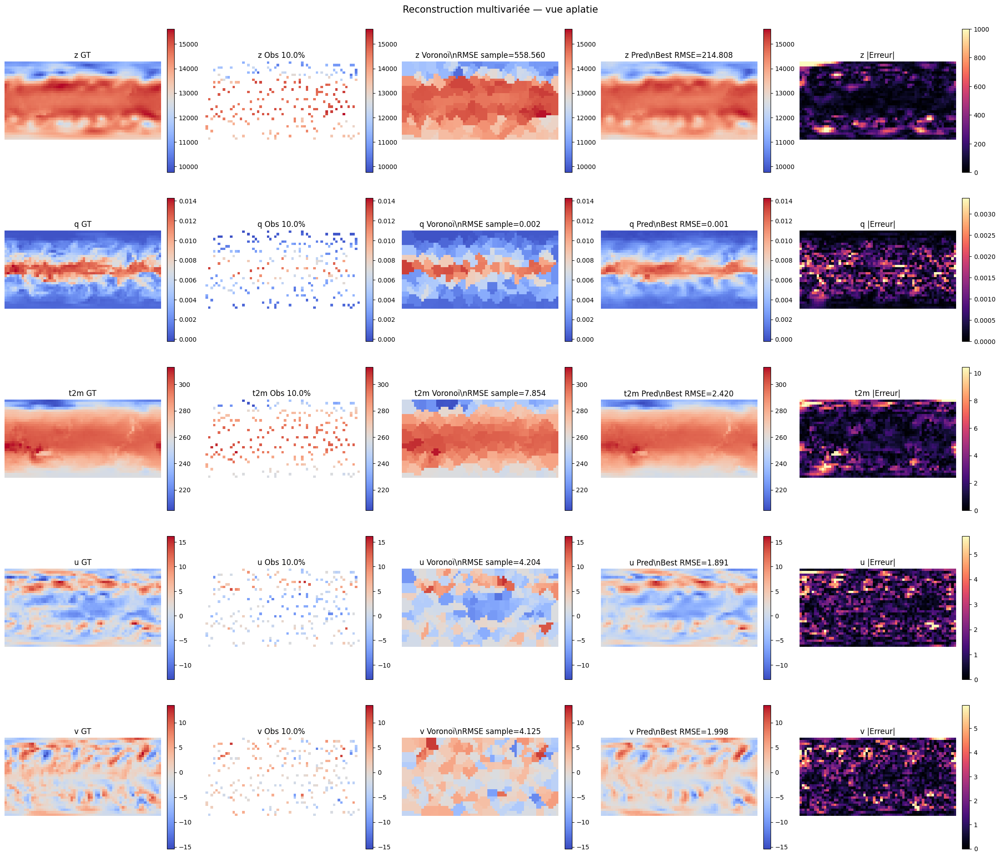

[F4] Visualisations affichées: 3
[F5] Vérification variation des masques...
  Train: diff moyen epoch1 vs epoch2 = 0.183594 (0 => identique)
  Val  : diff moyen accès A vs B = 0.000000 (attendu ~0)
  Test : diff moyen accès A vs B = 0.000000 (attendu ~0)


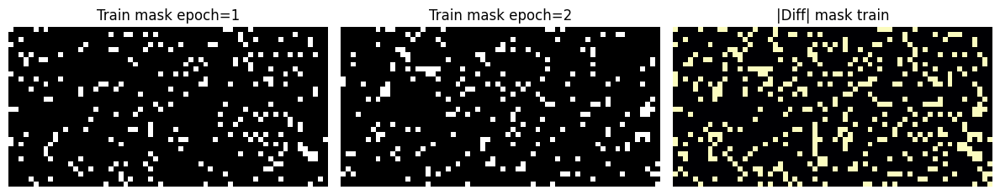

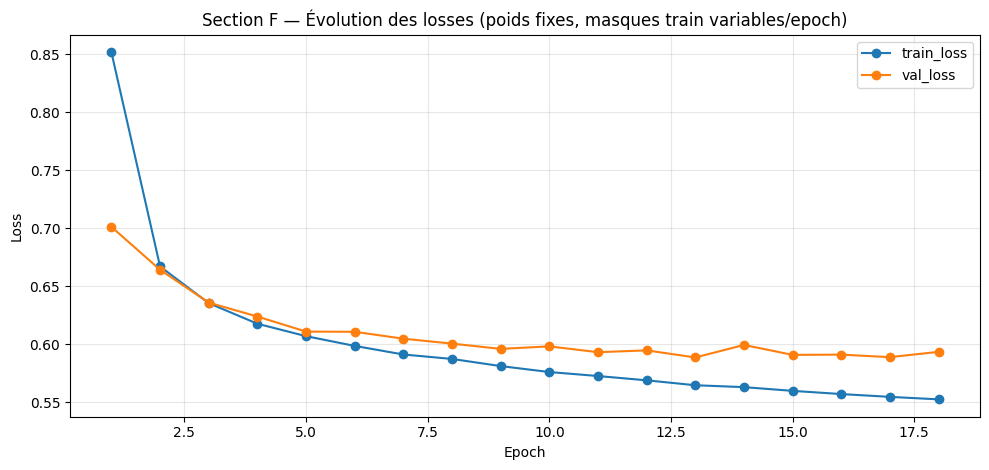

[F5] Courbe losses générée.
[F6] Protocole cross-densité: modèle F entraîné à 10% -> éval test 5%..49%
keep_ratio=5% | NRMSE=0.3589 | ACC=0.7823 | SSIM=0.7472
keep_ratio=6% | NRMSE=0.3346 | ACC=0.8132 | SSIM=0.7684
keep_ratio=7% | NRMSE=0.3189 | ACC=0.8309 | SSIM=0.7840
keep_ratio=8% | NRMSE=0.3013 | ACC=0.8494 | SSIM=0.7996
keep_ratio=9% | NRMSE=0.2898 | ACC=0.8605 | SSIM=0.8110
keep_ratio=10% | NRMSE=0.2785 | ACC=0.8709 | SSIM=0.8207
keep_ratio=11% | NRMSE=0.2689 | ACC=0.8796 | SSIM=0.8294
keep_ratio=12% | NRMSE=0.2604 | ACC=0.8870 | SSIM=0.8377
keep_ratio=13% | NRMSE=0.2538 | ACC=0.8924 | SSIM=0.8443
keep_ratio=14% | NRMSE=0.2469 | ACC=0.8981 | SSIM=0.8503
keep_ratio=15% | NRMSE=0.2405 | ACC=0.9030 | SSIM=0.8560
keep_ratio=16% | NRMSE=0.2352 | ACC=0.9069 | SSIM=0.8609
keep_ratio=17% | NRMSE=0.2304 | ACC=0.9106 | SSIM=0.8651
keep_ratio=18% | NRMSE=0.2254 | ACC=0.9142 | SSIM=0.8698
keep_ratio=19% | NRMSE=0.2214 | ACC=0.9171 | SSIM=0.8731
keep_ratio=20% | NRMSE=0.2173 | ACC=0.9197 | SS

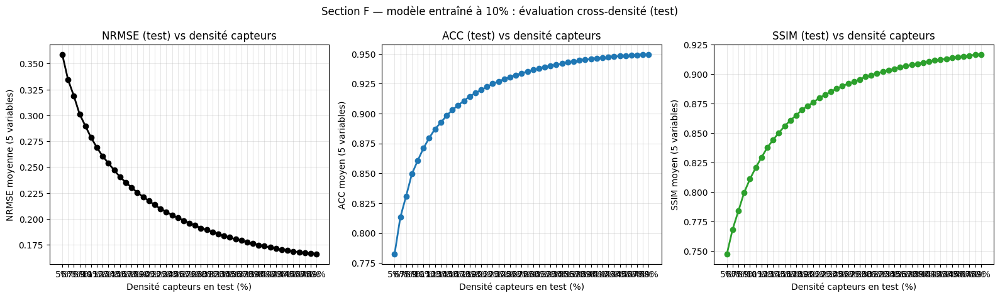

[F6] Courbes cross-densité générées.


In [28]:
# ── F4. Évaluation + comparaison C1 + qualitatif ───────────────────────────
print('── Résultats Section F (masque train variable/epoch) ──')
results_f = evaluate_multivariate(
    model_f, test_loader_f, keys_f, means_f, stds_f, device,
    climatology_maps=CLIM_MV_MAPS_F if "CLIM_MV_MAPS_F" in globals() else None,
    lat_weights_2d=LAT_WEIGHTS_2D_F if "LAT_WEIGHTS_2D_F" in globals() else None,
)
print_results_multivariate(results_f)


def f_mean_metric(results, metric_key: str, keys):
    return float(np.mean([results[k][metric_key] for k in keys]))

nrmse_f = f_mean_metric(results_f, 'nrmse_global', keys_f)
acc_f   = f_mean_metric(results_f, 'acc', keys_f)
ssim_f  = f_mean_metric(results_f, 'ssim', keys_f)

print('[F4] Moyennes F:')
print(f'  NRMSE global moyen : {nrmse_f:.4f}')
print(f'  ACC moyen          : {acc_f:.4f}')
print(f'  SSIM moyen         : {ssim_f:.4f}')

# Comparaison vs C1@10%
if 'results_by_ratio' in globals() and isinstance(results_by_ratio, dict) and len(results_by_ratio) > 0:
    ref_key_c1 = min(results_by_ratio.keys(), key=lambda r: abs(float(r) - 0.10))
    res_c1 = results_by_ratio[ref_key_c1]

    nrmse_c1 = f_mean_metric(res_c1, 'nrmse_global', keys_f)
    acc_c1   = f_mean_metric(res_c1, 'acc', keys_f)
    ssim_c1  = f_mean_metric(res_c1, 'ssim', keys_f)

    print('[F4] Comparaison vs C1 (StrongUNet fixe, keep_ratio≈10%):')
    print(f'  Ref key : {float(ref_key_c1):.2f}')
    print(f'  NRMSE : F={nrmse_f:.4f} | C1={nrmse_c1:.4f} | Δ={nrmse_f - nrmse_c1:+.4f}')
    print(f'  ACC   : F={acc_f:.4f}   | C1={acc_c1:.4f}   | Δ={acc_f - acc_c1:+.4f}')
    print(f'  SSIM  : F={ssim_f:.4f}  | C1={ssim_c1:.4f}  | Δ={ssim_f - ssim_c1:+.4f}')
else:
    print('[F4] results_by_ratio indisponible: comparaison C1 ignorée.')

# ── Qualitatif (même helper que B: globe + aplati) ───────────────────────
F_NUM_SAMPLES = 3
shown_f = min(F_NUM_SAMPLES, len(test_ds_f))
best_rmse_f = {k: results_f[k]['rmse_global'] for k in keys_f}

for sample_idx in range(shown_f):
    print(f'[F4] Visualisation sample test idx={sample_idx}')
    plot_multivariate_sample(
        model_f,
        test_ds_f,
        keys_f,
        means_f,
        stds_f,
        idx=sample_idx,
        device=device,
        best_rmse=best_rmse_f,
        ds_geo=ds_f,
    )

print(f'[F4] Visualisations affichées: {shown_f}')

# ── F5. Vérifications masques (train variable, eval stable) + courbe losses ──
print('[F5] Vérification variation des masques...')

if len(train_ds_f) > 0:
    i0 = 0
    train_ds_f.set_epoch(1)
    m_train_e1 = train_ds_f[i0][2][0].detach().cpu().numpy()
    train_ds_f.set_epoch(2)
    m_train_e2 = train_ds_f[i0][2][0].detach().cpu().numpy()
    train_diff_ratio = float(np.mean(np.abs(m_train_e1 - m_train_e2)))
    print(f'  Train: diff moyen epoch1 vs epoch2 = {train_diff_ratio:.6f} (0 => identique)')
else:
    m_train_e1 = m_train_e2 = None
    print('  Train: dataset vide, check ignoré.')

if len(val_ds_f) > 0:
    j0 = 0
    m_val_a = val_ds_f[j0][2][0].detach().cpu().numpy()
    m_val_b = val_ds_f[j0][2][0].detach().cpu().numpy()
    val_diff_ratio = float(np.mean(np.abs(m_val_a - m_val_b)))
    print(f'  Val  : diff moyen accès A vs B = {val_diff_ratio:.6f} (attendu ~0)')
else:
    m_val_a = m_val_b = None
    print('  Val: dataset vide, check ignoré.')

if len(test_ds_f) > 0:
    k0 = 0
    m_test_a = test_ds_f[k0][2][0].detach().cpu().numpy()
    m_test_b = test_ds_f[k0][2][0].detach().cpu().numpy()
    test_diff_ratio = float(np.mean(np.abs(m_test_a - m_test_b)))
    print(f'  Test : diff moyen accès A vs B = {test_diff_ratio:.6f} (attendu ~0)')
else:
    m_test_a = m_test_b = None
    print('  Test: dataset vide, check ignoré.')

# Visu masques train (epoch 1/2) + diff
if m_train_e1 is not None and m_train_e2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    axes[0].imshow(m_train_e1, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Train mask epoch=1')
    axes[0].axis('off')

    axes[1].imshow(m_train_e2, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Train mask epoch=2')
    axes[1].axis('off')

    axes[2].imshow(np.abs(m_train_e2 - m_train_e1), cmap='magma')
    axes[2].set_title('|Diff| mask train')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Courbe losses F
if 'hist_f' not in globals() or len(hist_f.get('epoch', [])) == 0:
    print('[F5] Aucun historique epoch parsé depuis train_model_fixed_weights_f.')
else:
    x = hist_f['epoch']
    plt.figure(figsize=(10, 4.8))
    plt.plot(x, hist_f['train_loss'], marker='o', label='train_loss')
    plt.plot(x, hist_f['val_loss'], marker='o', label='val_loss')
    plt.title('Section F — Évolution des losses (poids fixes, masques train variables/epoch)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print('[F5] Courbe losses générée.')


# ── F6. Protocole cross-densité (copie de C5 appliquée à F) ───────────────
import numpy as np
from torch.utils.data import DataLoader

F_EVAL_KEEP_RATIOS = [r / 100 for r in range(5, 50)]
f_cross_metrics = {'nrmse': [], 'acc': [], 'ssim': []}

print('[F6] Protocole cross-densité: modèle F entraîné à 10% -> éval test 5%..49%')

for keep_ratio_eval in F_EVAL_KEEP_RATIOS:
    test_mv_eval_f = MultiSparseVoronoiDataset(
        fields_f, keys_f, means_f, stds_f, idx_test_f,
        keep_ratio=keep_ratio_eval, base_seed=SEED_TEST
    )
    test_loader_eval_f = DataLoader(
        test_mv_eval_f,
        batch_size=F_BATCH_SIZE_EVAL,
        shuffle=False,
        num_workers=0,
    )

    res_eval_f = evaluate_multivariate(
        model_f, test_loader_eval_f, keys_f, means_f, stds_f, device,
        climatology_maps=CLIM_MV_MAPS_F if "CLIM_MV_MAPS_F" in globals() else None,
        lat_weights_2d=LAT_WEIGHTS_2D_F if "LAT_WEIGHTS_2D_F" in globals() else None,
    )

    nrmse_mean_f = float(np.mean([res_eval_f[k]['nrmse_global'] for k in keys_f]))
    acc_mean_f   = float(np.mean([res_eval_f[k]['acc'] for k in keys_f]))
    ssim_mean_f  = float(np.mean([res_eval_f[k]['ssim'] for k in keys_f]))

    f_cross_metrics['nrmse'].append(nrmse_mean_f)
    f_cross_metrics['acc'].append(acc_mean_f)
    f_cross_metrics['ssim'].append(ssim_mean_f)

    print(f"keep_ratio={keep_ratio_eval:.0%} | NRMSE={nrmse_mean_f:.4f} | ACC={acc_mean_f:.4f} | SSIM={ssim_mean_f:.4f}")

x_f = [100 * r for r in F_EVAL_KEEP_RATIOS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(x_f, f_cross_metrics['nrmse'], marker='o', linewidth=2, color='black')
axes[0].set_title('NRMSE (test) vs densité capteurs')
axes[0].set_xlabel('Densité capteurs en test (%)')
axes[0].set_ylabel('NRMSE moyenne (5 variables)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_f, f_cross_metrics['acc'], marker='o', linewidth=2, color='tab:blue')
axes[1].set_title('ACC (test) vs densité capteurs')
axes[1].set_xlabel('Densité capteurs en test (%)')
axes[1].set_ylabel('ACC moyen (5 variables)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_f, f_cross_metrics['ssim'], marker='o', linewidth=2, color='tab:green')
axes[2].set_title('SSIM (test) vs densité capteurs')
axes[2].set_xlabel('Densité capteurs en test (%)')
axes[2].set_ylabel('SSIM moyen (5 variables)')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks(x_f)
    ax.set_xticklabels([f"{int(v)}%" for v in x_f])

plt.suptitle('Section F — modèle entraîné à 10% : évaluation cross-densité (test)')
plt.tight_layout()
plt.show()
print('[F6] Courbes cross-densité générées.')
